In [5]:
import os
import json
import csv

# ===== Pistachio raw data 경로 설정 =====
# Pistachio extract 디렉토리 경로를 지정하세요 (JSON 파일들이 있는 폴더)
root_dir = os.environ.get("PISTACHIO_DIR", "")  # 환경변수로 설정하거나 아래 직접 지정
# root_dir = "/path/to/pistachio/extract"        # ← 직접 지정할 경우 주석 해제
out_path = "Raw_data_actiondetails_LIST.csv"

# ===== 유틸 =====
def norm_str(x):
    # 개행/탭 제거(탭은 CSV에서 구분자로 오인될 수 있음)
    return (x or "").replace("\r\n", " ").replace("\n", " ").replace("\t", " ").strip()

def is_list(x): return isinstance(x, list)
def is_dict(x): return isinstance(x, dict)

def extract_temp_and_time(parameters):
    temp_obj, time_val = "", ""
    if not is_list(parameters): return temp_obj, time_val
    for p in parameters:
        if not is_dict(p): continue
        ptype = (p.get("type", "") or "").lower()
        if ptype in ("temperature", "temp"):
            v  = p.get("value", None)
            tx = norm_str(p.get("text", ""))
            temp_obj = {"value": v, "text": ""} if v is not None else ({"value": "", "text": tx} if tx else "")
        elif ptype == "time":
            if p.get("value", None) is not None:
                time_val = p["value"]
    return temp_obj, time_val

def extract_components(components):
    out = []
    if not is_list(components): return out
    for comp in components:
        if not is_dict(comp): continue
        out.append({
            "role": comp.get("role", ""),
            "name": norm_str(comp.get("name", "")),
            "smiles": comp.get("smiles", ""),
            "quantities": comp.get("quantities", []) or []
        })
    return out

def extract_yield_for_action(act_type, components):
    if (act_type or "").lower() != "yield": return ""
    if not is_list(components): return ""
    for comp in components:
        if not is_dict(comp): continue
        for q in comp.get("quantities", []) or []:
            if (q.get("type","") or "").lower() == "yield" and q.get("value", None) is not None:
                return q["value"]
    return ""

# ===== CSV 헤더 =====
fieldnames = [
    "row_id",
    "Patent Title","Date","Quality","Reaction Class","Reaction Name","SMILES",
    "Reactants","Products","Catalysts","Agents","Solvents",
    "Action Order","Actions"
]

written = skipped_quality = parse_fail = 0
next_row_id = 1

with open(out_path, "w", newline="", encoding="utf-8-sig") as fout:
    writer = csv.DictWriter(
        fout,
        fieldnames=fieldnames,
        delimiter=",",
        quoting=csv.QUOTE_ALL,      # 모든 필드 큰따옴표로 감싸기
        quotechar='"',
        doublequote=True,           # 내부 " -> "" 로 이스케이프
        lineterminator="\n",
    )
    writer.writeheader()

    for subdir, _, files in os.walk(root_dir):
        for file in files:
            if not file.endswith(".json"):
                continue
            filepath = os.path.join(subdir, file)
            with open(filepath, encoding="utf-8") as fin:
                for line in fin:
                    try:
                        rxndata = json.loads(line)
                    except json.JSONDecodeError:
                        parse_fail += 1
                        continue

                    try:
                        data_value = rxndata.get("data", {}) or {}
                        quality = norm_str(data_value.get("qualityRank", "")).upper()
                        if quality not in ("S","A"):
                            skipped_quality += 1
                            continue

                        row = {
                            "row_id": next_row_id,
                            "Patent Title": norm_str(rxndata.get("title", "")),
                            "Date": data_value.get("date", ""),
                            "Quality": data_value.get("qualityRank", ""),
                            "Reaction Class": data_value.get("namerxn", ""),
                            "Reaction Name": data_value.get("namerxndef", ""),
                            "SMILES": data_value.get("smiles", ""),
                        }

                        # 역할별 SMILES
                        role_smiles = {"Product": [], "Reactant": [], "Catalyst": [], "Agent": [], "Solvent": []}
                        component_ls = rxndata.get("components", []) or []
                        if is_list(component_ls):
                            for comp in component_ls:
                                if not is_dict(comp): continue
                                role = comp.get("role", "")
                                smi  = comp.get("smiles", "")
                                if role in role_smiles and smi:
                                    role_smiles[role].append(smi)
                        row["Products"]  = ";".join(role_smiles["Product"])
                        row["Reactants"] = ";".join(role_smiles["Reactant"])
                        row["Catalysts"] = ";".join(role_smiles["Catalyst"])
                        row["Agents"]    = ";".join(role_smiles["Agent"])
                        row["Solvents"]  = ";".join(role_smiles["Solvent"])

                        # 액션들(리스트로 보존)
                        actions_out, order_seq = [], []
                        action_ls = rxndata.get("actions", []) or []
                        if is_list(action_ls):
                            for act in action_ls:
                                if not is_dict(act): continue
                                t = norm_str(act.get("type", ""))
                                temp_obj, time_val = extract_temp_and_time(act.get("parameters", []) or [])
                                comps_list = extract_components(act.get("components", []) or [])
                                yld = extract_yield_for_action(t, act.get("components", []) or [])

                                actions_out.append({
                                    "type": t,
                                    "Temperature": temp_obj,
                                    "Time": time_val,
                                    "Component": comps_list,
                                    "Text": norm_str(act.get("text", "")),
                                    "Yield": yld
                                })
                                order_seq.append(t)

                        row["Action Order"] = ";".join(order_seq)
                        # JSON 문자열(안에 탭이 들어있지 않게 이미 norm_str 처리)
                        row["Actions"] = json.dumps(actions_out, ensure_ascii=False)

                        writer.writerow(row)
                        written += 1
                        next_row_id += 1
                    except Exception:
                        parse_fail += 1
                        continue

print(f"✅ Done. Wrote {written} rows to: {out_path}")
print(f"   Skipped (quality != S/A): {skipped_quality}, Parse/other fails: {parse_fail}")


✅ Done. Wrote 13559071 rows to: Raw_data_actiondetails_LIST.csv
   Skipped (quality != S/A): 9026437, Parse/other fails: 0


In [1]:
import pandas as pd
import numpy as np
import os
import re
from collections import Counter
import re
from sklearn.model_selection import train_test_split
from rdkit import Chem
from rdkit.Chem import AllChem

pd.set_option('display.max_colwidth', None)

def clean_smiles_text(smiles):
    """불필요한 태그(|r|, |f| 등)와 공백 제거"""
    if not isinstance(smiles, str):
        return ''
    smiles = re.sub(r'\|[^\|]+\|', '', smiles)  # | 사이의 모든 문자 제거
    smiles = smiles.strip().replace(" ", "")
    return smiles

def clean_reaction(rxn):
    if not isinstance(rxn, str):
        # print("Not string:", rxn)
        return rxn
    if '>>' in rxn:
        # print(">> found:", rxn)
        return rxn
    # Reactants>Reagents>Products → Reactants>>Products
    parts = rxn.split('>')
    if len(parts) == 3:
        return parts[0] + '>>' + parts[2]  # Reagents(1번) 제거!
    elif len(parts) == 1:
        #   print("> 한개:", rxn)
        return rxn.replace('>', '>>')  # 단일 > → >>
    return rxn

def validate_atommapped_reaction(rxn):
    if not isinstance(rxn, str): return False
    try:
        parts = rxn.split('>>')
        if len(parts) != 2: return False
        
        # Atom mapping 포함 SMILES 검증
        react_mol = Chem.MolFromSmiles(parts[0])
        prod_mol = Chem.MolFromSmiles(parts[1])
        
        if react_mol is None or prod_mol is None:
            return False
        
        if react_mol == prod_mol:
            return False
            
        # RDKit Sanitize (atom mapping 검증)
        Chem.SanitizeMol(react_mol)
        Chem.SanitizeMol(prod_mol)
        
        # 빈 분자 체크
        if react_mol.GetNumAtoms() == 0 or prod_mol.GetNumAtoms() == 0:
            return False
        
        # 반응 전후에 분자가 그대로 있는 경우 걸러내기
        # → 양쪽에 동일한 분자가 있으면 유효하지 않음 (spectator 분자 포함)
        def get_canonical_molecules(molecule_str):
            """'.' 로 구분된 분자들을 canonical SMILES로 변환 (atom mapping 제거)"""
            canonical_set = set()
            for mol_str in molecule_str.split('.'):
                mol_str = mol_str.strip()
                if not mol_str:
                    continue
                try:
                    mol = Chem.MolFromSmiles(mol_str)
                    if mol is not None:
                        # atom mapping 제거
                        for atom in mol.GetAtoms():
                            atom.SetAtomMapNum(0)
                        canonical_smi = Chem.MolToSmiles(mol, canonical=True)
                        canonical_set.add(canonical_smi)
                except:
                    pass
            return canonical_set
        
        react_canonical = get_canonical_molecules(parts[0])
        prod_canonical = get_canonical_molecules(parts[1])
        
        # 양쪽에 모두 존재하는 분자들이 있으면 → 그냥 spectator 분자 포함 → False
        if len(react_canonical & prod_canonical) > 0:
            return False
            
        return True
    except:
        return False
    

from rdkit import Chem
from rdkit import RDLogger
import gc
RDLogger.DisableLog('rdApp.*')

def demap_multi(smis: str):
    if not isinstance(smis, str) or not smis.strip():
        return True, smis
    
    clean_list = []
    for smi in smis.split(";"):
        s = smi.strip()
        if not s:
            continue
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            return False, smis, f"RDKit failed to parse SMILES: {s}"
        for atom in mol.GetAtoms():
            atom.SetAtomMapNum(0)
        clean_list.append(Chem.MolToSmiles(mol, canonical=True))
    
    return True, ";".join(sorted(set(clean_list)))


In [4]:
import pandas as pd
import gc

valid_file = "Raw_rxn_R_P_R_Canon.csv"

# 필수 컬럼
cols = ["SMILES", "Reaction Class", "Reaction Name", "Reactants", "Products"]

COLS_TO_PROCESS = ["Reactants", "Products", "Catalysts", "Solvents", "Agents"]

# 청크 크기 설정 (메모리에 따라 조정 가능)
CHUNK_SIZE = 1000000

print("✅ 청크 단위로 데이터 처리 시작...")

# 출력 파일 초기화
first_chunk = True
total_raw = 0
total_valid_cols = 0
total_removed_cols = 0

total_valid_canon = 0
total_invalid_canon = 0

# 청크 단위로 읽기 및 처리
for chunk_num, df_chunk in enumerate(pd.read_csv("Raw_data_actiondetails_LIST.csv", chunksize=CHUNK_SIZE), 1):
    print(f"  처리 중: Chunk {chunk_num} ({len(df_chunk):,} 행)")
    total_raw += len(df_chunk)
    
    # 1. NaN 포함된 행
    df_nan_removed = df_chunk[df_chunk[cols].isna().any(axis=1)]
    
    # 2. NaN 제거 후 빈 문자열 포함된 행
    df_nonan = df_chunk.dropna(subset=cols)
    df_blank_removed = df_nonan[(df_nonan[cols] == "").any(axis=1)]
    
    # 추가 필터링: "Reaction Class"가 0 또는 "0"인 행 제거
    df_nonan = df_nonan[~((df_nonan["Reaction Class"] == 0) | (df_nonan["Reaction Class"] == "0"))]
    
    # 추가 필터링: "Reaction Name"이 "Unrecognized"인 행 제거
    df_nonan = df_nonan[df_nonan["Reaction Name"] != "Unrecognized"]
    
    # 3. 최종 정상 반응 (빈 문자열 없는 데이터)
    df_S = df_nonan[~(df_nonan[cols] == "").any(axis=1)].copy()
    
    # 4. 제거된 전체 합치기 (NaN + 빈 문자열)
    df_removed = pd.concat([df_nan_removed, df_blank_removed]).drop_duplicates()

    # 카운트 업데이트
    total_valid_cols += len(df_S)
    total_removed_cols  += len(df_removed)

    invalid_rows = []
    valid_indices = []
    
    for idx, row in df_S.iterrows():
        try:
            # SMILES 검증
            smiles_str = str(row['SMILES'])
            smiles_cleaned = clean_smiles_text(smiles_str)
            smiles_cleaned = clean_reaction(smiles_cleaned)
            
            if not validate_atommapped_reaction(smiles_cleaned):
                raise ValueError("Invalid SMILES")
            
            df_S.at[idx, 'SMILES'] = smiles_cleaned

            # 모든 컬럼 순서대로 검증 (에러나면 즉시 invalid로)
            col_updates = {}
            for col in COLS_TO_PROCESS:
                if col not in df_S.columns:
                    continue
                ok, new_val = demap_multi(row[col])
                if not ok:
                    raise ValueError(f"{col} error")
                col_updates[col] = new_val
            
            # 정상 행: 업데이트 반영
            for col, val in col_updates.items():
                df_S.at[idx, col] = val
            valid_indices.append(idx)
            
        except:
            # 어떤 에러든 invalid로 분류
            invalid_rows.append(row.to_dict())
        

    df_valid = df_S.loc[valid_indices].reset_index(drop=True)
    df_invalid = pd.DataFrame(invalid_rows)

    mode = 'w' if first_chunk else 'a'
    header = first_chunk

    df_valid.to_csv(valid_file, mode=mode, header=header, index=False)

    total_valid_canon += len(df_valid)
    total_invalid_canon += len(df_invalid)

    # if chunk_num % 10 == 0:
    #     print(f"  처리 중: {total_raw:,} 행 완료 (온도 있음: {total_valid_canon:,} / 없음: {total_invalid_canon:,})")

    first_chunk = False
    del df_chunk, df_nan_removed, df_nonan, df_blank_removed, df_S, df_removed, df_valid, df_invalid, invalid_rows, valid_indices
    gc.collect()


# ✅ 요약 출력
print(f"\n✅ 처리 완료!")
print(f"✅ 총 샘플: {total_raw:,}개")
print(f"✅ columns 있는 반응: {total_valid_cols:,}개 (이 중 정상: {total_valid_canon:,}개, 비정상: {total_invalid_canon:,}개)")
print(f"❌ columns 없는 반응: {total_removed_cols:,}개")
print(f"✅ columns 있는 반응 중 정상 반응: {total_valid_canon:,}개 → 'Raw_Yes_SMILES_Class_Name_R_P_data.csv'")

✅ 청크 단위로 데이터 처리 시작...
  처리 중: Chunk 1 (1,000,000 행)
  처리 중: Chunk 2 (1,000,000 행)
  처리 중: Chunk 3 (1,000,000 행)
  처리 중: Chunk 4 (1,000,000 행)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\2769562063.py:26: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df_chunk in enumerate(pd.read_csv("Raw_data_actiondetails_LIST.csv", chunksize=CHUNK_SIZE), 1):


  처리 중: Chunk 5 (1,000,000 행)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\2769562063.py:26: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df_chunk in enumerate(pd.read_csv("Raw_data_actiondetails_LIST.csv", chunksize=CHUNK_SIZE), 1):


  처리 중: Chunk 6 (1,000,000 행)
  처리 중: Chunk 7 (1,000,000 행)
  처리 중: Chunk 8 (1,000,000 행)
  처리 중: Chunk 9 (1,000,000 행)
  처리 중: Chunk 10 (1,000,000 행)
  처리 중: Chunk 11 (1,000,000 행)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\2769562063.py:26: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df_chunk in enumerate(pd.read_csv("Raw_data_actiondetails_LIST.csv", chunksize=CHUNK_SIZE), 1):


  처리 중: Chunk 12 (1,000,000 행)
  처리 중: Chunk 13 (1,000,000 행)
  처리 중: Chunk 14 (559,071 행)

✅ 처리 완료!
✅ 총 샘플: 13,559,071개
✅ columns 있는 반응: 13,507,447개 (이 중 정상: 13,073,226개, 비정상: 434,221개)
❌ columns 없는 반응: 51,068개
✅ columns 있는 반응 중 정상 반응: 13,073,226개 → 'Raw_Yes_SMILES_Class_Name_R_P_data.csv'


In [5]:
import pandas as pd
import json
from rdkit import RDLogger
import gc

RDLogger.DisableLog('rdApp.*')

def all_temperature_empty_dict(actions_json):
    try:
        actions = json.loads(actions_json) if isinstance(actions_json, str) else actions_json
    except Exception:
        return True
    if not isinstance(actions, list):
        return True
    for a in actions:
        if isinstance(a, dict):
            temp = a.get("Temperature", "")
            if isinstance(temp, dict):
                return False  # dict면 무조건 온도 정보 있음
            elif str(temp).strip() != "":
                return False
    return True

# 청크 단위 처리
CHUNK_SIZE = 5000000

# input_file = "test.csv"
# output_file_with_temp = "test_t.csv"
# output_file_without_temp = "test_wt.csv"

input_file = "Raw_rxn_R_P_R_Canon.csv"
output_file_with_temp = "Raw_rxn_R_P_R_Canon_withtemp.csv"
output_file_without_temp = "Raw_rxn_R_P_R_Canon_withouttemp.csv"

first_chunk = True
total_processed = 0
total_with_temp = 0
total_without_temp = 0

for chunk_num, df in enumerate(pd.read_csv(input_file, chunksize=CHUNK_SIZE, encoding="utf-8"), 1):
    print(f"총 {len(df)}개의 반응 처리 시작... (Chunk {chunk_num})")
    
    with_temp_indices = []
    without_temp_indices = []
    
    for idx, row in df.iterrows():
        if not all_temperature_empty_dict(row['Actions']):
            with_temp_indices.append(idx)
        else:
            without_temp_indices.append(idx)
    
    # 온도 정보가 있는 행
    df_with_temp = df.loc[with_temp_indices].reset_index(drop=True)
    # 온도 정보가 없는 행
    df_without_temp = df.loc[without_temp_indices].reset_index(drop=True)
    
    # 파일에 추가 저장
    mode = 'w' if first_chunk else 'a'
    header = first_chunk
    
    if not df_with_temp.empty:
        df_with_temp.to_csv(output_file_with_temp, mode=mode, header=header, index=False, encoding='utf-8')
    
    if not df_without_temp.empty:
        df_without_temp.to_csv(output_file_without_temp, mode=mode, header=header, index=False, encoding='utf-8')
    
    first_chunk = False
    
    total_processed += len(df)
    total_with_temp += len(df_with_temp)
    total_without_temp += len(df_without_temp)
    
    # 진행상황 출력
    if chunk_num % 10 == 0:
        print(f"  처리 중: {total_processed:,} 행 완료 (온도 있음: {total_with_temp:,} / 없음: {total_without_temp:,})")
    
    # 메모리 정리
    del df, df_with_temp, df_without_temp, with_temp_indices, without_temp_indices
    gc.collect()

print(f"\n✅ 온도 정보 있는 반응: {total_with_temp:,}개 → '{output_file_with_temp}'")
print(f"❌ 온도 정보 없는 반응: {total_without_temp:,}개 → '{output_file_without_temp}'")
print(f"📊 총 처리 행: {total_processed:,}개")

C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\3254774744.py:40: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file, chunksize=CHUNK_SIZE, encoding="utf-8"), 1):


총 5000000개의 반응 처리 시작... (Chunk 1)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\3254774744.py:40: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file, chunksize=CHUNK_SIZE, encoding="utf-8"), 1):


총 5000000개의 반응 처리 시작... (Chunk 2)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\3254774744.py:40: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file, chunksize=CHUNK_SIZE, encoding="utf-8"), 1):


총 3073226개의 반응 처리 시작... (Chunk 3)

✅ 온도 정보 있는 반응: 7,003,485개 → 'Raw_rxn_R_P_R_Canon_withtemp.csv'
❌ 온도 정보 없는 반응: 6,069,741개 → 'Raw_rxn_R_P_R_Canon_withouttemp.csv'
📊 총 처리 행: 13,073,226개


In [6]:
import pandas as pd
import json
from collections import defaultdict
import gc

INPUT_FILE = "Raw_rxn_R_P_R_Canon_withtemp.csv"
OUTPUT = "Raw_rxn_R_P_R_Canon_withtemp_tagged.csv"
CHUNK_SIZE = 3500000

# --- JSON 파서 (작따/공백 방어) ---
def parse_actions(actions_json):
    if actions_json is None:
        return []
    if isinstance(actions_json, list):
        return actions_json
    s = str(actions_json).strip()
    try:
        return json.loads(s)
    except json.JSONDecodeError:
        return json.loads(s.replace("'", '"'))

# --- 한 반응(actions 리스트)에 대해 type을 'Type[k]'로 태깅 ---
def tag_actions(actions):
    """
    actions: list[dict], 각 dict에 'type' 키가 있다고 가정
    return: (actions_tagged, order_tagged_str)
    """
    counts = defaultdict(int)   # 타입별 누적 등장 수
    tagged = []

    for a in actions:
        if not isinstance(a, dict):
            tagged.append(a)  # 이상 항목은 그대로
            continue
        t = (a.get("type", "") or "").strip()
        # 필요시 표준화(옵션): t = t.capitalize()
        counts[t] += 1
        k = counts[t]
        t_tag = f"{t}[{k}]"
        b = dict(a)          # 얕은 복사 후 수정
        b["type"] = t_tag
        tagged.append(b)

    # 태깅된 순서를 세미콜론으로 연결한 문자열 (예: 'Add[1];Stir[1];Add[2];...')
    order_tagged = ";".join(x.get("type", "") for x in tagged)
    return tagged, order_tagged

# --- 청크 단위로 처리 ---
first_chunk = True
total_processed = 0

print("✅ 청크 단위로 Actions 태깅 시작...")

for chunk_num, df_chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE), 1):
    print(f"  처리 중: Chunk {chunk_num} ({len(df_chunk):,} 행)")
    
    # 새 컬럼 추가(원본 보존)
    tagged_actions_str = []
    tagged_orders_str = []

    for _, row in df_chunk.iterrows():
        actions = parse_actions(row.get("Actions", "[]"))
        actions_tagged, order_tagged = tag_actions(actions)
        tagged_actions_str.append(json.dumps(actions_tagged, ensure_ascii=False))
        tagged_orders_str.append(order_tagged)

    df_chunk["Actions"] = tagged_actions_str           # 각 action의 type이 'Type[k]'
    df_chunk["Action Order"] = tagged_orders_str        # 'Add[1];Stir[1];Add[2];...'

    # 파일에 저장 (첫 청크는 헤더 포함, 이후는 append)
    mode = 'w' if first_chunk else 'a'
    header = first_chunk
    
    df_chunk.to_csv(OUTPUT, mode=mode, header=header, index=False)
    
    total_processed += len(df_chunk)
    first_chunk = False
    
    # 메모리 정리
    del df_chunk, tagged_actions_str, tagged_orders_str
    gc.collect()

print(f"\n✅ 처리 완료!")
print(f"✅ 총 처리된 행: {total_processed:,}개 → '{OUTPUT}'")

✅ 청크 단위로 Actions 태깅 시작...


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\156523349.py:54: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df_chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE), 1):


  처리 중: Chunk 1 (3,500,000 행)
  처리 중: Chunk 2 (3,500,000 행)
  처리 중: Chunk 3 (3,485 행)

✅ 처리 완료!
✅ 총 처리된 행: 7,003,485개 → 'Raw_rxn_R_P_R_Canon_withtemp_tagged.csv'


Main1 만들기
Main[1]
1. workupbase 중에서 Quench가 처음으로 발견된거면 그 앞은 다 Main으로 취급. 단, Quench에 Component가 없을 경우 아래의 규칙을 따름.
2. 나머지에 대해서는 Add 혹은 연속적인 Add 혹은 그 뒤에 Stir이 붙은 경우,아래의 규칙에 따라 Main에 포함시킬지 말지 결정함. 그 외는 다 Main[1]으로 취급함.
ex) Add;Extract, Add;Add;Extract, Add;Add;Add;Extract, Add;Add;Stir;Extract, Add;Stir;Extract
 1) workupbase 바로 앞에 Stir가 있는 경우:
	Stir의 Component에 Reactant가 있으면, Stir 포함 그 앞은 Main[1]으로 넣음.
	Stir의 Component에 Reactant가 없고, Unknown, Catalyst, Solvent, Agent 중 하나라도 있으면 Main[1]에 넣지 않음.
	Stir의 Component에 아무것도 없으면, Stir 바로 앞에 Add가 있으면 2) 규칙을 따르고, Add가 없으면 Main[1]에 넣음.
 2) workupbase 바로 앞에 Add가 있는 경우:
	가장 가까운 Add부터 확인해서 Component에 Reactant가 있으면 그 Add 포함해서 그 앞은 Main[1]에 넣기 (단, 그 Add 바로 뒤부터 Component가 있는지 순차적으로 확인하면서 Component가 있는 Action이 발견되면 그 앞까지 Main[1]에 포함시킴. 물론 workupbase부터는 확인조차 안해도 됨.)

Remove는 Quenching에서 제외
이유: Remove 중에서 solvent나 중간에 발생하는 부산물(ex:수소가스) 제거 같은게 있긴한데, Component에 Agent, Solvent, Catalyst로 적혀있지 않아서 문제되지 않음.
+ Remove가 ice-bath 제거하는게 많고 그 뒤에 main이랑 같이 있는게 많음. 그리고 Remove에서 Agent, Solvent이런거 들어있는거 살펴보면 95% 포함시키는게 맞다고 판단함


In [7]:
import re, json, ast
import pandas as pd
from typing import Any, List, Dict, Optional

WORKUP_BASES = {
    "Extract[1]", "Purify[1]", "Recover[1]", "Filter[1]", "Quench[1]",
    "Concentrate[1]", "Partition[1]", "Dry[1]", "Wash[1]", "PhChange[1]"
}
# Stir에 대해 제외 판단 시 쓰는 역할 집합
NON_REACTANT_ROLES = {"unknown", "catalyst", "solvent", "agent"}

# ---------------- 유틸 ----------------
def strip_index(tok: str) -> str:
    return re.sub(r"\[\d+\]$", "", tok.strip()) if isinstance(tok, str) else ""

def get_index(tok: str) -> int:
    m = re.search(r"\[(\d+)\]$", tok.strip()) if isinstance(tok, str) else None
    return int(m.group(1)) if m else 1

def parse_actions(s):
    if isinstance(s, list): return s
    if s is None or (isinstance(s, float) and pd.isna(s)): return []
    st = str(s).strip()
    if not st: return []
    for parser in (json.loads, lambda x: json.loads(x.replace("'", '"')), ast.literal_eval):
        try:
            v = parser(st)
            if isinstance(v, list): return v
            if isinstance(v, dict): return [v]
        except Exception:
            pass
    return []

def norm_components(obj) -> List[Dict[str, Any]]:
    if obj is None: return []
    if isinstance(obj, dict): return [obj]
    if isinstance(obj, list): return [c for c in obj if isinstance(c, dict)]
    return []

def get_action_by_type_nth(actions, base: str, nth: int) -> Optional[Dict[str, Any]]:
    """actions 리스트에서 base 타입의 nth번째 액션(dict) 반환 (없으면 None)"""
    cnt = 0
    for a in actions:
        if not isinstance(a, dict): 
            continue
        t = str(a.get("type", "")).strip()
        if strip_index(t).lower() == base.lower():
            cnt += 1
            if cnt == nth:
                return a
    return None

def has_role(a: Dict[str, Any], roles_lower: set) -> bool:
    comps = norm_components(a.get("Component", [])) if isinstance(a, dict) else []
    for c in comps:
        role = str(c.get("role") or c.get("Role") or "").strip().lower()
        if role in roles_lower:
            return True
    return False

def has_any_component(a: Dict[str, Any]) -> bool:
    comps = norm_components(a.get("Component", [])) if isinstance(a, dict) else []
    return len(comps) > 0

def add_run_start(tokens: List[str], pos_before: int) -> int:
    """pos_before (예: Stir 직전 위치)에서 뒤로 가며 연속 Add-run 시작 인덱스 반환"""
    j = pos_before
    while j >= 0 and strip_index(tokens[j]) == "Add":
        j -= 1
    return j + 1

# ---------------- 메인 함수: 새 규칙 반영 ----------------
def transform_action_order_with_before(order: str, actions_raw):
    """
    새 규칙 반영:
    1) 첫 워크업이 Quench인 경우,
       - Quench에 Component가 있으면: 그 앞 전부 Main
       - Quench에 Component가 없으면: 아래 Stir/Add 규칙으로 판단
    2) 그 외 워크업: Add/연속 Add/(Add 뒤 Stir) 규칙으로 판단, 나머지는 전부 Main
    """
    if not isinstance(order, str) or not order.strip():
        return pd.Series({"Before_Main[1]": "", "Action Order_Main[1]": order})

    tokens = [t.strip() for t in order.split(";") if t.strip()]
    if not tokens:
        return pd.Series({"Before_Main[1]": "", "Action Order_Main[1]": ""})

    # 첫 워크업 위치
    k = next((i for i, t in enumerate(tokens) if t in WORKUP_BASES), -1)

    # 워크업이 없으면 전체 Main
    if k == -1:
        before_main = ";".join(tokens)
        return pd.Series({"Before_Main[1]": before_main, "Action Order_Main[1]": ("Main[1]" if before_main else "")})

    first_workup_base = strip_index(tokens[k])
    actions = parse_actions(actions_raw)  # 아래에서 공통 사용

    # --- 1) Quench가 첫 워크업인 경우: Component 유무에 따라 분기 ---
    if first_workup_base == "Quench":
        q_nth = get_index(tokens[k])
        quench_act = get_action_by_type_nth(actions, "Quench", q_nth)
        if quench_act and has_any_component(quench_act):
            # 컴포넌트가 있으면: Quench 앞 전부 Main
            before_main = ";".join(tokens[:k]) if k > 0 else ""
            out = []
            if before_main:
                out.append("Main[1]")
            out.extend(tokens[k:])
            new_order = ";".join(out)
            return pd.Series({"Before_Main[1]": before_main, "Action Order_Main[1]": new_order})
        # 컴포넌트가 없으면 → 아래 일반 규칙으로 계속 처리(=fall-through)

    # --- 2) 일반 규칙 (Add/Stir 예외 판단; 그 외는 워크업 앞 전부 Main) ---

    # workup 바로 앞 토큰 기준 판단
    if k > 0:
        prev_tok = tokens[k-1]
        prev_base = strip_index(prev_tok)

        # 2-1) workup 바로 앞이 Stir 인 경우
        if prev_base == "Stir":
            nth = get_index(prev_tok)
            stir_act = get_action_by_type_nth(actions, "Stir", nth)

            if stir_act and has_role(stir_act, {"reactant"}):
                # Stir에 Reactant 있으면 Stir 포함 그 앞은 Main
                start_exclude = k  # workup부터는 Main 아님
            else:
                if stir_act and has_role(stir_act, NON_REACTANT_ROLES):
                    # Stir에 Unknown/Catalyst/Solvent/Agent 있으면 Main에 넣지 않음
                    add_start = add_run_start(tokens, k-2)  # Stir 직전 위치는 k-2
                    start_exclude = add_start if add_start < k-1 else k-1
                else:
                    # Stir 컴포넌트 없음 -> 직전이 Add면 규칙2 위임, 아니면 전부 Main
                    if k-2 >= 0 and strip_index(tokens[k-2]) == "Add":
                        start_exclude = _apply_rule2_add_block(tokens, actions, k, nearest_add_pos=k-2)
                    else:
                        start_exclude = k

            before_main = ";".join(tokens[:start_exclude]) if start_exclude > 0 else ""
            out = []
            if before_main:
                out.append("Main[1]")
            out.extend(tokens[start_exclude:])
            new_order = ";".join(out)
            return pd.Series({"Before_Main[1]": before_main, "Action Order_Main[1]": new_order})

        # 2-2) workup 바로 앞이 Add 인 경우 (또는 연속 Add 블록)
        if prev_base == "Add":
            start_exclude = _apply_rule2_add_block(tokens, actions, k, nearest_add_pos=k-1)
            before_main = ";".join(tokens[:start_exclude]) if start_exclude > 0 else ""
            out = []
            if before_main:
                out.append("Main[1]")
            out.extend(tokens[start_exclude:])
            new_order = ";".join(out)
            return pd.Series({"Before_Main[1]": before_main, "Action Order_Main[1]": new_order})

    # 2-3) 그 외: 워크업 앞 전부 Main
    before_main = ";".join(tokens[:k]) if k > 0 else ""
    out = []
    if before_main:
        out.append("Main[1]")
    out.extend(tokens[k:])
    new_order = ";".join(out)
    return pd.Series({"Before_Main[1]": before_main, "Action Order_Main[1]": new_order})

# ---------------- 규칙 2 구현 함수 ----------------
def _apply_rule2_add_block(tokens: List[str], actions, k: int, nearest_add_pos: int) -> int:
    """
    규칙 2)
    - workup 바로 앞에 Add가 있는 경우 (혹은 Stir 컴포넌트 없음 + 직전이 Add라서 위임된 경우)
    - 가장 가까운 Add부터 뒤로 가며(연속 Add 체인) Reactant가 있는 Add를 찾음
      - 찾으면: 그 Add '포함' 및 그 앞 전부 Main
        단, 그 Add 바로 뒤부터 k-1까지 순차 확인하면서 'Component 있는 액션'이 나오면
        그 '바로 앞'까지를 Main으로 포함 (workup 구간은 확인 X)
      - 못 찾으면: Add-run 자체는 Main에 포함하지 않음 (즉, Add-run 시작부터 제외)
    반환값: start_exclude (해당 index부터는 Main이 아님)
    """
    # 연속 Add-run의 시작 인덱스 찾기 (nearest_add_pos에서 뒤로)
    add_start = nearest_add_pos
    while add_start >= 0 and strip_index(tokens[add_start]) == "Add":
        add_start -= 1
    add_start += 1  # 첫 Add 위치

    # 가장 가까운 Add부터 뒤로 가며 Reactant를 갖는 Add 찾기
    include_from_pos = None
    j = nearest_add_pos
    while j >= add_start and strip_index(tokens[j]) == "Add":
        nth = get_index(tokens[j])
        add_act = get_action_by_type_nth(actions, "Add", nth)
        if add_act and has_role(add_act, {"reactant"}):
            include_from_pos = j
            break
        j -= 1

    if include_from_pos is None:
        # Reactant 가진 Add가 하나도 없으면 Add-run은 포함 X → run 시작부터 제외
        return add_start

    # include_from_pos 포함 + 그 앞 전부 Main으로 잡되,
    # 그 Add 바로 뒤부터 k-1까지 'Component 있는 액션' 만나면 그 '앞'까지만 Main
    cut = k  # 기본: workup 직전까지 포함
    for tpos in range(include_from_pos + 1, k):
        base = strip_index(tokens[tpos])
        nth = get_index(tokens[tpos])
        act = get_action_by_type_nth(actions, base, nth)
        if act and has_any_component(act):
            cut = tpos  # 이 액션 '앞'까지만 포함
            break

    # cut 위치부터는 Main이 아님
    return cut

import gc

CHUNK_SIZE = 2500000

input_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged.csv"
output_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main.csv"

first_chunk = True
total_processed = 0

for chunk_num, df in enumerate(pd.read_csv(input_file, chunksize=CHUNK_SIZE, encoding="utf-8"), 1):
    print(f"총 {len(df)}개의 반응 처리 시작... (Chunk {chunk_num})")

    df[["Before_Main[1]", "Action Order_Main[1]"]] = df.apply(
        lambda r: transform_action_order_with_before(r["Action Order"], r["Actions"]), 
        axis=1
    )

    mode = 'w' if first_chunk else 'a'
    header = first_chunk
    
    df.to_csv(output_file, mode=mode, header=header, index=False, encoding='utf-8-sig')
    
    total_processed += len(df)
    first_chunk = False
    
    print(f"✅ Chunk {chunk_num} 처리 완료: {len(df):,} 행 저장 (누적: {total_processed:,})")
    
    # 메모리 정리
    del df
    gc.collect()

print(f"\n✅ 전체 처리 완료: {total_processed:,}개 → '{output_file}'")

C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\2190849524.py:226: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file, chunksize=CHUNK_SIZE, encoding="utf-8"), 1):


총 2500000개의 반응 처리 시작... (Chunk 1)
✅ Chunk 1 처리 완료: 2,500,000 행 저장 (누적: 2,500,000)
총 2500000개의 반응 처리 시작... (Chunk 2)
✅ Chunk 2 처리 완료: 2,500,000 행 저장 (누적: 5,000,000)
총 2003485개의 반응 처리 시작... (Chunk 3)
✅ Chunk 3 처리 완료: 2,003,485 행 저장 (누적: 7,003,485)

✅ 전체 처리 완료: 7,003,485개 → 'Raw_rxn_R_P_R_Canon_withtemp_tagged_main.csv'


Main[1]_Actions: 메인 전 단계의 액션들만, 필요한 필드만 남긴 JSON.

Main[1]_Temp: 메인 전 단계에서 추출된 대표 온도(숫자).

Main[1]_Temp_text: 숫자를 못 뽑았을 때 온도 관련 텍스트.

Main1_Comp: 메인 전 단계에서 등장하는 모든 Component의 축약 정보(JSON).

Main1_Reactant, Main1_Catalyst, Main1_Agent, Main1_Solvent: 역할별로 분리한 SMILES 목록(세미콜론 구분)

Main[1]_Actions에서 최종적으로 대표 온도 값을 뽑습니다.

safe_load로 JSON 리스트로 파싱(문자열이 아니거나 비어 있으면 None).

각 스텝의 "Temperature"를 다시 safe_load로 파싱(문자열인 경우 dict로 변환).

temp["value"]가 채워져 있으면 values 리스트에, temp["text"]는 texts에 모읍니다.

values가 있으면 그 중 최대값을 Main[1]_Temp로, Main[1]_Temp_text는 None.

값이 하나도 없으면 Main[1]_Temp는 None, 대신 texts를 "; "로 join해서 Main[1]_Temp_text에 넣습니다

In [8]:
import json
import pandas as pd
import re

def safe_load(x):
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return None
        try:
            return json.loads(x)
        except Exception:
            return None
    return x

def keep_before_main(row):
    # 1) Before_Main[1]에서 몇 개의 단계인지 계산
    before = row["Before_Main[1]"]  # 예: "Add[1];Heat[1];Unknown[1];Stir[1];Add[2];Stir[2]"
    if pd.isna(before) or before == "":
        k = 0
    else:
        before_types = [t for t in before.split(";") if t]  # 공백 제거
        k = len(before_types)

    # 2) Actions 로드
    steps = json.loads(row["Actions"])

    # 3) 앞에서부터 k개만 남기기 (Before_Main[1]에 해당하는 부분)
    before_steps = steps[:k]

    # 4) type + Temperature만 남기기
    reduced = []
    for s in before_steps:
        reduced.append({
            "type": s.get("type"),
            "Temperature": s.get("Temperature", ""),
            "Component": s.get("Component",[]) or s.get("Components", [])
        })

    # 필요에 따라: 리스트 그대로 둘지, JSON 문자열로 저장할지 선택
    return json.dumps(reduced, ensure_ascii=False)

def parse_set(s):
    """';'로 split 후 공백 제거, 빈 값 제외 → set 반환"""
    if not isinstance(s, str) or not s.strip():
        return set()
    return {x.strip() for x in s.split(";") if x.strip()}

def extract_temp_from_text(text):
    if not isinstance(text, str):
        return None
    
    # "째" 또는 "°" 앞의 패턴에서 첫 숫자만 추출
    m = re.search(
        r'([0-9]+(?:\s*[-–]\s*[0-9]+|\s+between\s+[0-9]+)?)\s*[째°]', 
        text
    )
    if not m:
        return None

    span = m.group(1)       # "70-72", "70 - 72", "70 between 72", "0"
    m2 = re.search(r'([0-9]+)', span)
    if not m2:
        return None
    return float(m2.group(1))

ZERO_TOKENS = {
    "0 - 5 ℃", "0 - 5ºc", "0 -10 ℃", "0 -10℃", "0 -20 ℃", "0 -25 ℃", "0 -25℃", "-0 oC",
    "0 -5 ℃", "0 celsius", "0 deg", "0 deg c", "0 degree", "0 degree celsius",
    "0 degrees", "0 degrees c", "0 degrees celsius", "0 degrees centigrade",
    "0 o c", "0 oc", "0 oc to rt", "0 oc to r.t.", "0 oc to rt",
    "0 oc – room temperature", "0 oc-rt", "0 oc.", "0 oc~10 oc", "0 oc~r.t.",
    "0 to 10 degrees c", "0 to 10 oc", "0 to 10oc", "0 to 10℃",
    "0 to 25 oc", "0 to 4 ℃", "0 to 5 oc", "0 to 5 ºc", "0 ~ 5 ℃",
    "0 º c", "0 ºc", "0 ºc - 5 ºc", "0 ºc to 25 ºc", "0 ºc.",
    "0 ℃", "0 ℃ to 10 ℃", "0 ℃ to 20 ℃", "0 ℃ to 25 ℃", "0 ℃ to rt",
    "0 ℃ to r.t.", "0 ℃ to rt", "0 ℃.", "0 ℃～rt", "0 ℃～rt",
    "0 ～ 25 ℃", "0 ～ 4 ℃", "0 ～ 5 ℃",
    "0-10 degrees c", "0-10 oc", "0-10 ℃", "0-10oc", "0-10℃",
    "0-15 ℃", "0-2 ºc", "0-20 ℃", "0-20℃", "0-25 ℃", "0-25oc", "0-25℃",
    "0-4 ℃", "0-5 oc", "0-5 ºc", "0-5 ℃", "0-50 ℃", "0-5oc", "0-5ºc", "0-5℃",
    "0-degree", "0deg c", "0o c", "0oc", "0oc to rt", "0oc to rt", "0oc.",
    "0oc~room temperature", "0~10 oc", "0~10 ℃", "0~5 oc", "0~5oc",
    "0º", "0º c", "0ºc", "0ºc ~ 5ºc", "0ºc-room temp",
    "0℃", "0℃ -rt", "0℃ to rt", "0℃ to rt", "0℃ ～ rt",
    "0℃ ～ room temperature", "0℃ ～ rt", "0℃-10℃", "0℃-5℃", "0℃.",
    "0℃～10℃", "0℃～rt", "0−5 oc", "0～10℃", "0～19℃", "0～20 ℃", "0～5 ℃", "0～5℃",
    "about 0 degrees", "about 0 oc", "about 0 ºc", "about 0 ℃",
    "about 0-10ºc", "about 0ºc", "about 0℃",
    "below 0 oc", "below 0 ℃", "below 0ºc",
    "zero degree", "zero degrees", "zero degrees c", "zero degrees celsius",
    "zero ° c", "zero °c", "∼0 degrees celsius", "˜0 degrees Celsius","~0 degrees Celsius",
    'zero degree', 'zero degrees', 'zero degrees C', 'zero degrees Celsius', 'zero degrees Centigrade',

    "zero degree Celsius",
    "zero ° C",
    "zero ° C.; zero ° C.; zero ° C.",
    "zero °C",
    "zero °C; zero °C",
}
ZERO_TOKENS = {t.lower().strip() for t in ZERO_TOKENS}

RT_TOKENS = {
    "rt", "RT", "ambient temperature","room temperature", "to room temperature",
    "~ rt", 'R.T', 'R.T.', 'about RT', 'about room temperature', 'ambient temp', 'ambient temp.', 'ambient tem\xadperature', 'around room temperature', 'below RT', 'below room temperature', 'r.t', 'r.t.', 'room temp', 'room temp.', 'room temperature approximately', 'room tempera\xadture', 'room temper\xadature', 'room tem\xadperature', '~ rt', '˜room temperature', '˜rt', '∼ rt',
    "r.t", "r.t.",
    "room temp", "room temp.",
    "room temperature approximately",
    "room temper­ature", "room tempera­ture",
    "room tempe­rature", "room temp­erature", "room tem­perature",
    "rt", "r.t", "r.t.", "r.t;",  # 여유 있게 추가해도 됨
    "room temp", "room temp.",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "room temperature approximately",
    "room tempera­ture", "room temper­ature",
    "room tempe­rature", "room temp­erature", "room tem­perature",
    "r.t", "r.t.",
    "room temp", "room temp.",
    "ambient temp", "ambient temp.",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "about rt", "about rt.",
    "about room temperature",
    "about ambient temperature",
    "around room temperature",
    "about rt",
    "about 25ºc", "about 25℃",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "room temp", "room temp.",
    "rt", "r.t", "r.t.",
    "～ 25℃", "～25 ℃", "～25℃",
    "˜room temperature", "˜rt", "∼ rt", "below ambient temperature", "below room temperature",

    "> RT",
    "> room temperatur",
    "above RT",
    "above room temperature",
    "ambient temperature to RT",
    "ambient temperature",
    "approximately room temperature",
    "around ambient temperature",
    "around rt",
    "at least room temperature",
    "ca. room temperature",
    "room temperature or below",
    "room temperature or lower",
    "roughly ambient temperature",

}
RT_TOKENS = {t.lower().strip() for t in RT_TOKENS}

other_temp_tokens_75 = {"seventy- five degrees Celsius"}
other_temp_tokens_85 = {"eighty-five degrees Celsius"}

import re
def parse_single_temp_token(tok: str):

    if not isinstance(tok, str):
        return None
    t = tok.strip().lower()

    # 0 계열
    if t in ZERO_TOKENS:
        return 0.0

    # RT 계열
    if t in RT_TOKENS:
        return 25.0

    # 숫자 기반: 맨 앞 숫자만 사용 (음수/소수 포함)
    nums = re.findall(r'-?\d+\.?\d*', t)
    if nums:
        first = float(nums[0])
        return first

    return None

def fill_temp_value_from_text(s):
    if pd.isna(s) or s == "":
        return s

    try:
        steps = json.loads(s)
    except Exception:
        return s

    for step in steps:
        temp = step.get("Temperature", None)

        # Temperature가 dict인 경우
        if isinstance(temp, dict):
            v = temp.get("value", "")
            t = temp.get("text", "")
            if (v in ("", None)):
                if isinstance(t, str) and ("째" in t or "°" in t):
                    parsed = extract_temp_from_text(t)
                    if parsed is not None:
                        temp["value"] = parsed
                elif isinstance(t, str):
                    parsed = parse_single_temp_token(t)
                    if parsed is not None:
                        temp["value"] = parsed    

    return json.dumps(steps, ensure_ascii=False)

def parse_temp(s):
    steps = safe_load(s)
    if not steps:
        return pd.Series({"Main[1]_Temp": None,
                          "Main[1]_Temp_text": None})

    values, texts = [], []

    for step in steps:
        temp = step.get("Temperature", None)

        # Temperature도 문자열일 수 있으니 한 번 더 파싱
        temp = safe_load(temp)
        if not temp:
            continue

        v = temp.get("value", "")
        t = temp.get("text", "")

        if v not in ("", None):
            values.append(v)
        if t:
            texts.append(t)

    if values:
        main_val = max(values)
        main_txt = None
    else:
        main_val = None
        main_txt = "; ".join(texts) if texts else None

    return pd.Series({"Main[1]_Temp": main_val,
                      "Main[1]_Temp_text": main_txt})

import json
from typing import List, Dict, Any, Tuple, Optional, Union

def _project_component_fields(comp: Dict[str, Any]) -> Dict[str, Any]:
    """Component에서 role, name, smiles만 추출"""
    def pick(d, keys):
        for k in keys:
            if k in d and d[k] not in (None, "", []):
                return d[k]
        return None
    role   = pick(comp, ["role", "Role"])
    name   = pick(comp, ["name", "Name", "component_name", "ComponentName"])
    smiles = pick(comp, ["smiles", "SMILES", "Smiles"])
    role   = str(role).strip()   if isinstance(role, (str, int, float)) and role is not None else None
    name   = str(name).strip()   if isinstance(name, (str, int, float)) and name is not None else None
    smiles = str(smiles).strip() if isinstance(smiles, (str, int, float)) and smiles is not None else None
    return {"role": role, "name": name, "smiles": smiles}

def make_main1_comp(row):
    """
    Main[1]_Actions (JSON 문자열) 안에서
    모든 step의 Component들을 한 리스트로 모은 뒤
    JSON 문자열로 저장 (나중에 split_comp_to_roles에 그대로 사용)
    """
    s = row["Main[1]_Actions"]
    if not isinstance(s, str) or not s.strip():
        return ""

    try:
        steps = json.loads(s)
    except Exception:
        return ""

    # step들이 [{"type":..,"Temperature":..,"Component":[...]}] 형식이라고 가정
    comps_flat = []
    for step in steps:
        comps = step.get("Component", []) or step.get("Components", []) or []
        # 리스트가 맞는지만 체크
        if isinstance(comps, list):
            for c in comps:
                if isinstance(c, dict):
                    comps_flat.append(_project_component_fields(c))

    # 나중에 split_comp_to_roles는 JSON 문자열을 받으니 그대로 dumps
    return json.dumps(comps_flat, ensure_ascii=False)

def _get(d, keys):
    for k in keys:
        if isinstance(d.get(k), str) and d[k].strip():
            return d[k].strip()
    return None

def normalize_role(s: str) -> str:
    s = (s or "").strip().lower()
    if s in {"reactant","reagent-reactant","substrate"}: return "Reactant"
    if s in {"product"}: return "Product"
    if s in {"catalyst"}: return "Catalyst"
    if s in {"agent","reagent","additive","base","acid","oxidant","reducing agent"}: return "Agent"
    if s in {"solvent","co-solvent"}: return "Solvent"
    return "Unknown"

def split_comp_to_roles(comp_json_str: str):
    buckets = {
        "Reactant": [], "Product": [], "Catalyst": [],
        "Agent": [], "Solvent": [], "Unknown": []
    }
    if not isinstance(comp_json_str, str) or not comp_json_str.strip():
        return {k: "" for k in buckets}

    # JSON 파싱 (작은따옴표 호환)
    try:
        comps = json.loads(comp_json_str)
    except Exception:
        try:
            comps = json.loads(comp_json_str.replace("'", '"'))
        except Exception:
            return {k: "" for k in buckets}

    if not isinstance(comps, list):
        return {k: "" for k in buckets}

    for c in comps:
        if not isinstance(c, dict):
            continue
        role_raw = _get(c, ["role","Role"])
        role = normalize_role(role_raw or "")
        smiles = _get(c, ["smiles","SMILES","Smiles"])
        if smiles:
            buckets[role].append(smiles)

    # 여러 개면 ; 로 연결
    return {k: ";".join(v) if v else "" for k, v in buckets.items()}


import gc
import pandas as pd

CHUNK_SIZE = 2000000
# input_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main_100.csv"

input_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main.csv"
output_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main_temp_comp.csv"

first_chunk = True
total_processed_df = 0
total_processed_df_empty = 0

for chunk_num, df in enumerate(pd.read_csv(input_file,
                                           chunksize=CHUNK_SIZE,
                                           encoding="utf-8"),
                               1):
    print(f"총 {len(df):,}개의 반응 처리 시작... (Chunk {chunk_num})")

    # --- 여기부터가 기존 for i in range(1, 11) 안의 내용에 해당 ---

    # 1) 메인 전 단계 Actions 만들기
    df["Main[1]_Actions"] = df.apply(keep_before_main, axis=1)

    # 2) 온도 정보 처리
    df["Main[1]_Actions"] = df["Main[1]_Actions"].apply(fill_temp_value_from_text)
    temp_parsed = df["Main[1]_Actions"].apply(parse_temp)
    df = pd.concat([df, temp_parsed], axis=1)


    # 3) Component 처리
    df["Main1_Comp"] = df.apply(make_main1_comp, axis=1)

    split_cols = df["Main1_Comp"].apply(split_comp_to_roles)
    df["Main1_Catalyst"] = split_cols.map(lambda d: d["Catalyst"])
    df["Main1_Agent"]    = split_cols.map(lambda d: d["Agent"])
    df["Main1_Solvent"]  = split_cols.map(lambda d: d["Solvent"])

    
    # 온도 없는 것과 분리
    mask_nonempty = (
        df["Main[1]_Temp"].notna()
        & (df["Main[1]_Temp"].astype(str).str.strip() != "")
    )
    print(
        f"[Temp] Total rows: {len(df):,} | "
        f"Non-empty Temp: {mask_nonempty.sum():,} | "
        f"Empty Temp: {(~mask_nonempty).sum():,}"
    )
    df_temp = df[mask_nonempty]
    df_empty = df[~mask_nonempty]

    # --- 여기까지가 chunk 단위 전처리 ---

    # 4) chunk별로 결과를 한 output 파일에 append
    mode = "w" if first_chunk else "a"
    header = first_chunk

    df_temp.to_csv(output_file, mode=mode, header=header,
              index=False, encoding="utf-8-sig")
    df_empty.to_csv(output_file.replace(".csv", "_tempempty.csv"), mode=mode, header=header, index=False, encoding="utf-8-sig")
    total_processed_df += len(df_temp)
    total_processed_df_empty += len(df_empty)
    first_chunk = False

    print(
        f"✅ Chunk {chunk_num} 처리 완료: 온도 있는 {len(df_temp):,} 행 저장, 온도 없는 {len(df_empty):,} 행 저장 "
        f"(누적(온도 O): {total_processed_df:,} \n누적(온도 X): {total_processed_df_empty:,})"
    )

    # 메모리 정리
    del df
    del df_empty
    gc.collect()

C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\4151334239.py:353: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file,


총 2,000,000개의 반응 처리 시작... (Chunk 1)
[Temp] Total rows: 2,000,000 | Non-empty Temp: 1,912,465 | Empty Temp: 87,535
✅ Chunk 1 처리 완료: 온도 있는 1,912,465 행 저장, 온도 없는 87,535 행 저장 (누적(온도 O): 1,912,465 
누적(온도 X): 87,535)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\4151334239.py:353: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file,


총 2,000,000개의 반응 처리 시작... (Chunk 2)
[Temp] Total rows: 2,000,000 | Non-empty Temp: 1,899,882 | Empty Temp: 100,118
✅ Chunk 2 처리 완료: 온도 있는 1,899,882 행 저장, 온도 없는 100,118 행 저장 (누적(온도 O): 3,812,347 
누적(온도 X): 187,653)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\4151334239.py:353: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file,


총 2,000,000개의 반응 처리 시작... (Chunk 3)
[Temp] Total rows: 2,000,000 | Non-empty Temp: 1,910,309 | Empty Temp: 89,691
✅ Chunk 3 처리 완료: 온도 있는 1,910,309 행 저장, 온도 없는 89,691 행 저장 (누적(온도 O): 5,722,656 
누적(온도 X): 277,344)


C:\Users\MICC\AppData\Local\Temp\ipykernel_87444\4151334239.py:353: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, df in enumerate(pd.read_csv(input_file,


총 1,003,485개의 반응 처리 시작... (Chunk 4)
[Temp] Total rows: 1,003,485 | Non-empty Temp: 950,977 | Empty Temp: 52,508
✅ Chunk 4 처리 완료: 온도 있는 950,977 행 저장, 온도 없는 52,508 행 저장 (누적(온도 O): 6,673,633 
누적(온도 X): 329,852)


In [ ]:
import pandas as pd
import os

base_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main_temp_comp.csv"
append_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main_temp_comp_temptext_only_withvalue.csv"
out_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main_temp_comp_MERGED.csv"

chunksize = 2500000  # 상황에 맞게 50k~500k 조절

# 1) base를 청크로 그대로 write
first = True
total = 0
for chunk in pd.read_csv(base_file, encoding="utf-8-sig", chunksize=chunksize):
    chunk.to_csv(out_file, index=False, encoding="utf-8-sig", mode="w" if first else "a", header=first)
    total += len(chunk)
    first = False

# 2) append를 헤더 없이 추가
df_append = pd.read_csv(append_file, encoding="utf-8-sig")
df_append.to_csv(out_file, index=False, encoding="utf-8-sig", mode="a", header=False)

print("✅ merged:", total + len(df_append), "(base:", total, ", append:", len(df_append), ")")


In [2]:
import pandas as pd
import math


base_file = "Raw_rxn_R_P_R_Canon_withtemp_tagged_main_temp_comp.csv"
out_file = "Raw_rxn_R_P_R_Canon_Temp.csv"

# cols = ['Patent Title', 'Date', 'Quality', 'Reaction Class', 'Reaction Name',
#        'SMILES', 'Reactants', 'Products', 'Catalysts', 'Agents', 'Solvents', 'Main[1]_Temp',]


cols_2 = [
    'row_id', 'Patent Title', 'Date', 'Quality', 'Reaction Class', 'Reaction Name',
    'SMILES', 'Reactants', 'Products', 'Catalysts', 'Agents', 'Solvents', 'Reagents', 'Main[1]_Temp',
]

base_cols = ["Catalysts", "Solvents", "Agents"]

next_row_id = 0

def split_cell(x):
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return []
    if not isinstance(x, str):
        x = str(x)
    return [s.strip() for s in x.split(";") if s.strip()]

def join_unique(items):
    return ";".join(sorted(set(items))) if items else ""

def union_from_cols(row, cols):
    items = []
    for c in cols:
        items.extend(split_cell(row.get(c, "")))
    return join_unique(items)



chunksize = 2500000  # 상황에 맞게 50k~500k 조절

# 1) base를 청크로 그대로 write
first = True
total = 0
for chunk_num, chunk in enumerate(
    pd.read_csv(base_file, encoding="utf-8-sig", chunksize=chunksize),
    start=1):
    chunk["Reagents"] = chunk.apply(lambda r: union_from_cols(r, base_cols), axis=1)
    chunk = chunk[cols_2]

    chunk.to_csv(out_file, index=False, encoding="utf-8-sig", mode="w" if first else "a", header=first)
    total += len(chunk)
    first = False
    print(f"✅ Chunk {chunk_num} 처리 완료: {len(chunk):,} 행 저장 (누적: {total:,})")

del chunk, chunk_num

C:\Users\MICC\AppData\Local\Temp\ipykernel_114172\4021534502.py:44: DtypeWarning: Columns (9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(


✅ Chunk 1 처리 완료: 2,500,000 행 저장 (누적: 2,500,000)


C:\Users\MICC\AppData\Local\Temp\ipykernel_114172\4021534502.py:44: DtypeWarning: Columns (9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(


✅ Chunk 2 처리 완료: 2,500,000 행 저장 (누적: 5,000,000)


C:\Users\MICC\AppData\Local\Temp\ipykernel_114172\4021534502.py:44: DtypeWarning: Columns (9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk_num, chunk in enumerate(


✅ Chunk 3 처리 완료: 1,673,633 행 저장 (누적: 6,673,633)


In [ ]:
import pandas as pd

def sort_cell(cell):
    if pd.isna(cell) or not cell.strip():
        return ""
    parts = [s.strip() for s in cell.split(";") if s.strip()]
    parts_sorted = sorted(parts)
    return ";".join(parts_sorted)


INPUT = "Raw_rxn_R_P_R_Canon_Temp.csv"
OUTPUT = f"Raw_rxn_R_P_R_Canon_Temp_unique_smiles.csv"
OUT_KEYS = "Raw_rxn_R_P_R_Canon_Temp_keys_smiles.csv"

df = pd.read_csv(INPUT, dtype=str, encoding="utf-8-sig")

# 키 생성
df["RP_key"] = df["SMILES"]
df["Full_key"] = df["RP_key"] + "::" + df["Reagents"].astype(str)


df_keys = df[["row_id","RP_key", "Full_key"]].copy()
df_keys.to_csv(OUT_KEYS, index=False)

print("RP_key unique   :", df_keys["RP_key"].nunique())
print("Full_key unique :", df_keys["Full_key"].nunique())

df_unique = df.drop_duplicates(subset="Full_key", keep="first").copy()
print("rows after unique Full_key :", len(df_unique))

cols_2 = [
    'row_id', 'Patent Title', 'Date', 'Quality', 'Reaction Class', 'Reaction Name',
    'SMILES', 'Reactants', 'Products', 'Catalysts', 'Agents', 'Solvents', 'Reagents', 'Main[1]_Temp',
]

df_unique = df_unique[cols_2]

df_unique.to_csv(OUTPUT, index=False, encoding="utf-8-sig")

수작업 정제 전 분포

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick  
from collections import Counter

def count_reagents(cell):
    if pd.isna(cell) or not cell.strip():
        return 0
    return len([x for x in cell.split(";") if x.strip()])

def plot_distribution_with_cumulative(df, cols, font_size=16, figsize = (14, 10), row = 2, col = 2):
    """
    시약 개수 분포 및 누적 분포를 표시하는 함수
    - 숫자는 지수(과학적 표기법)으로 표시
    - font_size로 전체 글자 크기 조절 가능
    - 100%는 한 번만 표시
    """
    fig, axes = plt.subplots(row, col, figsize=figsize)
    axes = axes.flatten()

    for i, col in enumerate(cols):
        count_series = df[col].apply(count_reagents)
        dist = count_series.value_counts().sort_index()
        cumulative = dist.cumsum() / dist.sum() * 100

        ax1 = axes[i]
        dist.plot(kind="bar", ax=ax1, color='skyblue', width=0.7)

        # --- 축, 제목, 글자 크기 설정 ---
        ax1.set_title(f"{col} Count Distribution", fontsize=font_size + 2)
        ax1.set_xlabel(f"Number of {col}", fontsize=font_size)
        ax1.set_ylabel("Frequency", fontsize=font_size)
        ax1.tick_params(axis='x', labelsize=font_size - 2)
        ax1.tick_params(axis='y', labelsize=font_size - 2)

        # --- 지수(과학적 표기법) 표시 ---
        ax1.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
        ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

        # --- 오른쪽 축: 누적 비율 ---
        ax2 = ax1.twinx()
        ax2.plot(cumulative.index, cumulative.values, color='red', marker='o', linestyle='--')
        ax2.set_ylabel("Cumulative Percentage (%)", fontsize=font_size)
        ax2.tick_params(axis='y', labelsize=font_size - 2)
        ax2.set_ylim(0, 110)

        # --- 누적 % 텍스트 표시 (100%는 한 번만) ---
        shown_100 = False
        for x, y in zip(cumulative.index, cumulative.values):
            if y >= 99.99:
                if not shown_100:
                    ax2.text(x, 102, "100%", ha='center', va='bottom',
                             fontsize=font_size - 2, color='red')
                    shown_100 = True
                continue  # 이후 100%는 표시 안 함
            ax2.text(x, y + 2, f"{y:.1f}%", ha='center', va='bottom',
                     fontsize=font_size - 2, color='red')

        ax2.legend(["Cumulative %"], loc="lower right", fontsize=font_size - 2)

    plt.tight_layout()
    plt.show()


def get_frequent_set(df, threshold=30):
    # combined 다시 만들 필요 없으면 기존 Main[1]_Reagents를 사용
    all_reagents_flat = []
    for x in df["Reagents"].dropna():
        all_reagents_flat.extend([r.strip() for r in str(x).split(";") if r.strip()])
    counts = Counter(all_reagents_flat)
    rare = {r for r, c in counts.items() if c < threshold}
    frequent = set(counts.keys()) - rare
    return frequent, counts

def contains_only_frequent(reagent_str, frequent_set):
    if pd.isna(reagent_str) or reagent_str.strip() == "":
        return True
    reagents = [r.strip() for r in reagent_str.split(";") if r.strip()]
    return all(r in frequent_set for r in reagents)


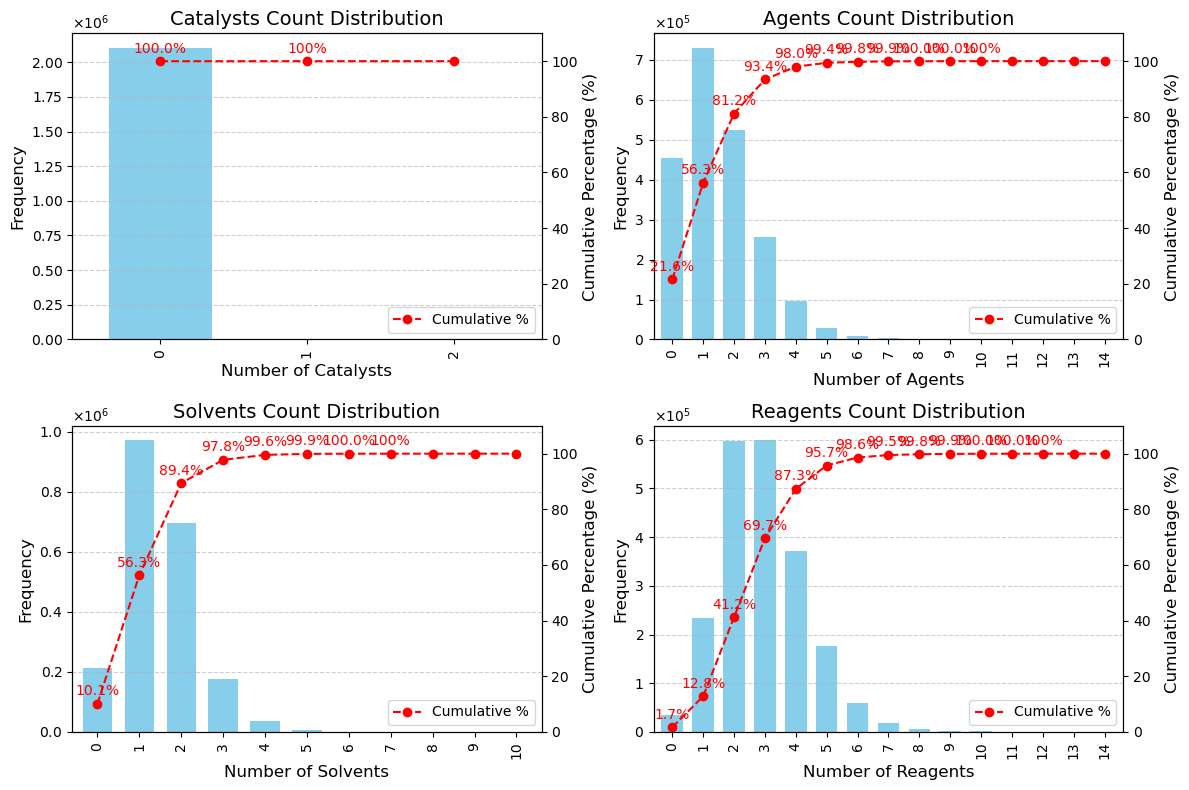

In [20]:
cols = ['Catalysts', 'Agents', 'Solvents', 'Reagents']
plot_distribution_with_cumulative(df_unique, cols, font_size=12, figsize=(12, 8), row=2, col=2)

In [21]:
import pandas as pd

# 현재 로드된 df 사용
# (만약 df가 메모리에 없으면 아래 경로에서 로드)

df = df_unique

# Catalysts 개수별 분포
catalysts_count = df['Catalysts'].apply(count_reagents)
catalysts_dist = catalysts_count.value_counts().sort_index()

print("=" * 50)
print("📊 Catalysts 개수별 반응 분포")
print("=" * 50)
for num, cnt in catalysts_dist.items():
    pct = cnt / len(df) * 100
    print(f"Catalysts = {num}: {cnt:,} 반응 ({pct:.2f}%)")

print(f"\n🎯 Catalyst = 1인 반응: {catalysts_dist.get(1, 0):,}개")

# 다른 컬럼들도 함께 보기
print("\n" + "=" * 50)
print("📊 다른 컬럼 개수별 분포 요약")
print("=" * 50)

for col in ['Agents', 'Solvents', 'Catalyst', 'Agent', 'Solvent']:
    if col in df.columns:
        count_dist = df[col].apply(count_reagents).value_counts().sort_index()
        print(f"\n{col} = 1: {count_dist.get(1, 0):,}개 / 전체: {count_dist.sum():,}개")

📊 Catalysts 개수별 반응 분포
Catalysts = 0: 2,103,059 반응 (99.99%)
Catalysts = 1: 262 반응 (0.01%)
Catalysts = 2: 2 반응 (0.00%)

🎯 Catalyst = 1인 반응: 262개

📊 다른 컬럼 개수별 분포 요약

Agents = 1: 729,418개 / 전체: 2,103,323개

Solvents = 1: 971,662개 / 전체: 2,103,323개


In [ ]:
import pandas as pd
import os

df = pd.read_csv('Raw_rxn_R_P_R_Canon_Temp_unique_smiles.csv')

import pandas as pd
from collections import Counter

# 3. 빈 줄 제외하고 리스트화
all_lines = df[df['Reagents'] != '']['Reagents'].tolist()

# 4. 모든 시약을 split하여 전체 빈도수 계산
all_reagents_flat = []
for line in all_lines:
    line = str(line).strip()  # NaN이나 다른 타입을 문자열로 변환
    if line and line != 'nan':  # 빈 문자열이나 'nan' 문자열 제외
        all_reagents_flat.extend([x.strip() for x in line.split(';') if x.strip()])

counts = Counter(all_reagents_flat)

# 5. 결과 확인
rare_reagents_50 = {reagent: count for reagent, count in counts.items() if count > 100}
rare_reagents_40 = {reagent: count for reagent, count in counts.items() if count > 50 and count <= 100}
rare_reagents_30 = {reagent: count for reagent, count in counts.items() if count <= 50}


print(f"총 반응 수: {len(all_lines)}")
print(f"전체 고유 시약 수: {len(counts)}")
print(f"100번 이상 등장 시약 수: {len(rare_reagents_50)}")
print(f"50-100번 등장 시약 수: {len(rare_reagents_40)}")
print(f"50번 이하 등장 시약 수: {len(rare_reagents_30)}")

C:\Users\MICC\AppData\Local\Temp\ipykernel_114172\3804399449.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Raw_rxn_R_P_R_Canon_Temp_unique_smiles.csv')


총 반응 수: 2103323
전체 고유 시약 수: 66685
100번 이상 등장 시약 수: 984
50-100번 등장 시약 수: 444
50번 이하 등장 시약 수: 65257


Reagent 수작업 정제 과정

규칙1) water_reagent_map에서 물 있는 것들은 물 다 지우기
      full_solvent_water_map 에서도 물 다 지우기 (co-solvent이긴 한데 수용액 느낌이라..)


In [ ]:
import pandas as pd

SOLVENTS_ALL = {
 'C1CCCCC1': 'cyclohexane',
 'C1CCOC1': 'THF',
 'C1COCCO1': '1,4-dioxane',
 'CC#N': 'MeCN;acetonitrile',
 'CC(=O)N(C)C': 'DMA;dimethylacetamide',
 'CC(C)(C)O': 't-BuOH;tert-butanol',
 'CC(C)=O': 'acetone',
 'CC(C)CO': 'i-BuOH;isobutanol',
 'CC(C)O': 'isopropanol',
 'CC(Cl)Cl': '1,1-dichloroethane;ethylidene chloride',
 'CC1CCCO1': '2-MeTHF;2-methyl-THF',
 'CCC(C)=O': 'MEK;butanone',
 'CCCCC': 'pentane',
 'CCCCCC': 'hexane',
 'CCCCCCC': 'heptane',
 'CCCCO': 'n-BuOH;n-butanol',
 'CCCO': '1-propanol',
 'CCO': 'EtOH;ethanol',
 'CCOC(C)=O': 'EtOAc;ethyl acetate',
 'CCOCC': 'Et2O;diethyl ether',
 'CN(C)C=O': 'DMF',
 'CN(C)P(=O)(N(C)C)N(C)C': 'HMPA',
 'CN1CCCC1=O': 'N-methyl-2-pyrrolidone;NMP',
 'CO': 'MeOH;methanol',
 'COC(C)(C)C': 'MTBE;Methyl tert-butyl ether;methyl tert-butyl ether',
 'COCCOC': '1,2-DME;DME',
 'CS(C)=O': 'DMSO',
 'Cc1ccc(C)cc1': 'p-xylene',
 'Cc1cccc(C)c1': 'm-xylene',
 'Cc1ccccc1': 'toluene',
 'Cc1ccccc1C': 'o-xylene',
 'ClC(Cl)(Cl)Cl': 'CCl4;carbon tetrachloride',
 'ClC(Cl)Cl': 'chloroform',
 'ClCCCl': '1,2-dichloroethane',
 'ClCCl': 'DCM;dichloromethane',
 'Clc1ccccc1': 'chlorobenzene',
 'Clc1ccccc1Cl': '1,2-dichlorobenzene',
 'O': 'water',
 'OCCO': 'ethylene glycol',
 'S=C=S': 'CS2;carbon disulfide',
 'c1ccccc1': 'benzene',
 'C1CCCC1': 'cyclopentane',
 'CNC(C)=O': 'N-methylacetamide',
 'CC(=O)O': 'acetic acid',
 'C[N+](=O)[O-]': 'nitromethane',
 'O=C(O)C(F)(F)F': 'TFA',
 'c1ccncc1': 'pyridine',
 'C1COCCOCCOCCOCCO1': 'EYO',
 'CC(=O)C#N': 'AcCN',
 'CC=C(C)C': 'pentene',
 'CCCC#N': 'butyronitrile',
 'CCCC(C)O': '2-pentanol',
 'CCCCCCCCCCCC': 'dodecane',
 'COC': 'dimethyl ether',
 'COC(C)=O': 'methyl acetate',
 'COC1CCCC1': 'CPME',
 'CS(C)(=O)=O': 'DMSO2',
 'CSC': 'DMS',
 'Cc1ccc(C(C)C)cc1': 'p-cymene',
 'N#Cc1ccccc1': 'benzonitrile',
 'OC(C(F)(F)F)C(F)(F)F': 'HFIP',
 'OCC(F)(F)F': 'TFE',
 'OCc1ccccc1': 'benzyl alcohol',
 '[2H]C(Cl)(Cl)Cl': 'CDCl3',
 'c1ccsc1': 'thiophene',
 'CC(=O)CC(C)C': '4-methylpentan-2-one;MIBK',
 'CC(=O)OC(C)C': 'isopropyl acetate',
 'CC(C)CCO': '3-methyl-1-butanol;isoamyl alcohol',
 'CC(C)OC(C)C': 'DIPE;diisopropyl ether',
 'CCC#N': 'propionitrile',
 'CCC(C)(C)O': 'tert-amyl alcohol',
 'CCC(C)O': '2-butanol;s-BuOH',
 'CCCC(C)C': 'isohexane',
 'CCCCCO': '1-pentanol;pentanol',
 'CCCCOC(C)=O': 'butyl acetate',
 'CCCCOCCCC': 'butyl ether;dibutyl ether',
 'CCOCCO': '2-ethoxyethanol',
 'CCc1ccccc1': 'ethylbenzene',
 'CN1CCN(C)C1=O': '1,3-dimethyl-2-imidazolidinone;DMI',
 'COCC(C)O': '1-methoxy-2-propanol;methoxyisopropanol',
 'COCCO': '2-methoxyethanol;methoxyethanol',
 'COCCOCCOC': 'diglyme',
 'COc1ccccc1': 'anisole',
 'Cc1cc(C)cc(C)c1': 'mesitylene',
 'O=S1(=O)CCCC1': 'sulfolane',
 'OCC(O)CO': 'glycerin;glycerol',
 'OCC1CCCO1': 'THFA',
 'OCCOCCO': 'diethylene glycol',
 'c1ccc(Oc2ccccc2)cc1': 'diphenyl ether',
 'CC(=O)OC(C)(C)C': 'tert-butyl acetate',
 'CC=O': 'acetaldehyde',
 'CN1CCCN(C)C1=O': 'DMPU',
 'COC(C)O': '1-methoxyethanol',
 'FC(F)(F)c1ccccc1': 'trifluorotoluene',
 'O=[N+]([O-])c1ccccc1': 'nitrobenzene',
 'Oc1ccccc1': 'phenol'
 }

WATER =  {'O': 'water'}

def split_to_set(s):
    return {x.strip() for x in s.split(";") if x.strip()}

solvent_keys = set(SOLVENTS_ALL.keys())
water = set(WATER.keys())

# df_unique 로드
df_unique = pd.read_csv('Raw_rxn_R_P_R_Canon_unique_smiles.csv', dtype=str)

full_solvent_water_map = {}
full_solvent_map = {}
water_reagent_map = {}
solvent_reagent_map = {}
no_solvent_reagent_map = {}

for s in df_unique['Reagents'].dropna():
    reagents = split_to_set(s)
    for reagent in reagents:
        fragments = {frag.strip() for frag in reagent.split(".") if frag.strip()}
        if not fragments:
            continue
        if len(fragments) > 1:
            # 1) 모든 조각이 solvent에 있는데 water가 포함된 경우
            if fragments.issubset(solvent_keys) and (fragments & water):
                full_solvent_water_map[reagent] = fragments
            # 2) 모든 조각이 solvent에 있는데 water가 포함되지 않은 경우
            elif fragments.issubset(solvent_keys):
                full_solvent_map[reagent] = fragments
            # 3) .으로 나눈 것중에 water가 있는 경우
            elif any(frag in water for frag in fragments):
                water_reagent_map[reagent] = fragments
            elif any(frag in solvent_keys for frag in fragments):
                solvent_reagent_map[reagent] = fragments
            # 4) 다른 reagent로만 이루어진 경우
            else:
                no_solvent_reagent_map[reagent] = fragments

import pandas as pd
from collections import Counter

maps = {
    'full_solvent_water_map': full_solvent_water_map,
    'full_solvent_map': full_solvent_map,
    'water_reagent_map': water_reagent_map,
    'solvent_reagent_map': solvent_reagent_map,
    'no_solvent_reagent_map': no_solvent_reagent_map,
}

# 각 map에 대해 count
for map_name, mapping in maps.items():
    map_keys = set(mapping.keys())
    key_counts = Counter()
    
    # df_unique의 각 row에서 Reagents를 파싱
    for reagents in df_unique['Reagents'].fillna(''):
        # ;로 나눔
        reagents_list = [r.strip() for r in reagents.split(';') if r.strip()]
        
        # 각 reagent가 map_keys에 있는지 확인하고 count
        for reagent in reagents_list:
            if reagent in map_keys:
                key_counts[reagent] += 1
    
    # DataFrame으로 변환
    df_result = pd.DataFrame(
        sorted(key_counts.items(), key=lambda x: x[1], reverse=True),
        columns=['key', 'count']
    )
    
    # CSV 저장
    filename = f'before_rule_{map_name}_key_counts_in_df.csv'
    df_result.to_csv(filename, index=False, encoding='utf-8-sig')
    
    print(f"✅ {filename}: {len(df_result)}개 unique key, total count: {key_counts.total()}")

print("\n모든 map의 key count 저장 완료!")


✅ before_rule_full_solvent_water_map_key_counts_in_df.csv: 203개 unique key, total count: 36568
✅ before_rule_full_solvent_map_key_counts_in_df.csv: 668개 unique key, total count: 47028
✅ before_rule_water_reagent_map_key_counts_in_df.csv: 843개 unique key, total count: 165698
✅ before_rule_solvent_reagent_map_key_counts_in_df.csv: 1695개 unique key, total count: 74036
✅ before_rule_no_solvent_reagent_map_key_counts_in_df.csv: 5933개 unique key, total count: 377832

모든 map의 key count 저장 완료!


다음 규칙을 이용해서 데이터를 고칠거야. 규칙 1부터 적용해서 규칙 4까지 차례차례 고치면 돼.
Catalysts, Solvents, Agents, Reagents를 각각 ; 으로 나눈 후에 각 규칙에 해당하는 map의 key와 일치하면 처리해주는거야.

규칙 1
solvent.reagent.water 혹은 solvent.water 혹은 reagent.water의 경우 (water_reagent_map, full_solvent_water_map)
- water_reagent_map의 key에 해당되는 경우 O 다 지우기
- full_solvent_water_map의 key에 해당되는 경우 O 다 지우기
ex) solvent.reagent.O -> solvent.reagent / solvent.O.O.reagent -> solvent.reagent


규칙 2
solvent.reagent의 경우 (solvent_reagent_map의 key에 해당되는 경우)
1) 만약 기존 시약들에서 solvent 키나 solvent.solvent 키가 있을 경우, solvent를 지우고 reagent만 남김 (문제점: 배위결합.. CCOCC.[Br][Mg][Br] WO2017037616A1_0169)
- sol1.sol1.sol1.reag1.reag1 -> reag1
- sol1.sol1.sol1.reag1.reag2. -> reag1.reag2
- sol1.sol2.reag1 -> reag1
- sol1.reag1.reag2 -> reag1.reag2

2 기존 solvent가 없으면, sol과 reag를 분리해서 넣기
- sol1.sol1.sol1.reag1.reag1 -> sol1;reag1
- sol1.sol1.sol1.reag1.reag2. -> sol1;reag1.reag2
- sol1.sol2.reag1 -> sol1;sol2;reag1
- sol1.reag1.reag2 -> sol1;reag1.reag2

규칙 3
solvent.solvent의 경우 (solvent_map의 key에 해당되는 경우)
1) 기존 SOLVENTS 목록에 있는 단일 용매가 있다면,solvent.solvent는 지우기 (이런 경우 보통 cosolvent가 아니라 크로마토그래피이거나 후처리 용매임)
    - sol1.sol1.sol1 -> 
    - sol1.sol2 -> 
2) 단일 용매가 발견되지 않았다면, solvent.solvent는 분리해서 넣음
    - sol1.sol1.sol1 -> sol1
    - sol1.sol2 -> sol1;sol2

규칙 4 - 현재는 일단 뺌
reagent.reagnet의 경우 (no_solvent_reagent_map의 key에 해당되는 경우)
1) 중복되는 것 합치기
    - reag1.reag1.reag2 -> reag1.reag2
    - reag1.reag1.reag2.reag3 -> reag1.reag2.reag3
    - reag1.reag2.reag3 -> reag1.reag2.reag3


그 후 Catalysts, Solvents, Agents, Reagents를 각각 ;으로 나눈 후 set로 중복제거하고 sorted해서 저장해줘.

위의 작업에서 변화하는 것들은 다 기록해줘야돼.
예를 들어서 sol1.sol1.sol1.reag1.reag1 -> reag1, reag1 -> reag1, sol1.sol2.reag1 -> reag1 이었으
Reagent_SMILES     count         detail
reag1            total count     reag1 : count, sol1.sol1.sol1.reag1.reag1 : count, sol1.sol2.reag1: count

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit import RDLogger
from collections import defaultdict

# RDKit 경고 끄기
RDLogger.DisableLog('rdApp.*')

# ==========================================
# 1. 헬퍼 함수
# ==========================================

def canonicalize_smiles(smiles):
    """SMILES 표준화 (실패 시 원본 반환)"""
    if not smiles or not isinstance(smiles, str) or smiles.strip() == '':
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return smiles
        return Chem.MolToSmiles(mol)
    except:
        return smiles

def canon_list(smiles_list):
    """리스트 내 모든 SMILES를 Canonicalize하고 빈 값 제거"""
    return [canonicalize_smiles(s) for s in smiles_list if s and s.strip()]

# 이력 추적용: { Final_Canonical_SMILES : { Original_SMILES : count } }
history_tracker = defaultdict(lambda: defaultdict(int))

# ==========================================
# 2. Map 및 설정 준비
# ==========================================

# ★ (실행 전 Map 변수 로드 필수)
water_reagent_map = water_reagent_map
full_solvent_water_map = full_solvent_water_map
solvent_reagent_map = solvent_reagent_map
full_solvent_map = full_solvent_map
no_solvent_reagent_map = no_solvent_reagent_map

# KNOWN_SOLVENTS 준비: 용매 판별용 (Canonical form으로 저장)
KNOWN_SOLVENTS = set(SOLVENTS_ALL.keys())

# ==========================================
# 3. 상세 처리 로직 (Row 단위)
# ==========================================

def process_row(row):
    target_cols = ['Catalysts', 'Solvents', 'Agents']
    
    # 데이터 구조: { col_name : [(original_str, current_str), ...] }
    # 원본 추적을 위해 튜플로 관리합니다.
    temp_data = {col: [] for col in target_cols}

   # -------------------------------------------------------
    # [Pass 1] 파싱 및 규칙 1(Water 제거) 우선 적용
    # -------------------------------------------------------
    for col in target_cols:
        raw_val = str(row[col])
        if not raw_val.strip(): continue
        
        raw_items = [item.strip() for item in raw_val.split(';') if item.strip()]
        
        for orig in raw_items:
            next_parts = []
            
            # [규칙 1] Water Map 처리
            if orig in water_reagent_map:
                comps = [x for x in water_reagent_map[orig] if x != 'O'] # Set: {'A', 'B', 'O'} -> ['A', 'B'] (O 제거)
                if comps:
                    next_parts.append('.'.join(sorted(comps))) # 남은 성분이 있으면 .으로 연결해서 하나로 합침 ('A.B') / comps가 비어있으면(즉, 'O'만 있어서 다 지워짐) next_parts는 빈 리스트 []
                
            elif orig in full_solvent_water_map:
                comps = [x for x in full_solvent_water_map[orig] if x != 'O'] # Set: {'Sol', 'O'} -> ['Sol']
                if comps:
                    next_parts.append('.'.join(sorted(comps)))
                
            else:
                next_parts.append(orig)
            
            # 중간 표준화
            cleaned_parts = canon_list(next_parts)
            
            # ★ [수정] 삭제된 경우에도 (orig, None)으로 저장하여 이력 추적 가능하게 함
            if not cleaned_parts:
                temp_data[col].append((orig, None))
            else:
                for p in cleaned_parts:
                    temp_data[col].append((orig, p))

    # -------------------------------------------------------
    # [Intermediate] 기존 시약에 '용매(Pure Solvent)' 존재 여부 판단
    # -------------------------------------------------------
    has_pure_solvent = False
    for col in target_cols:
        for _, curr_smi in temp_data[col]:
            if '.' not in curr_smi: # 단일 분자
                if curr_smi in KNOWN_SOLVENTS:
                    has_pure_solvent = True
                    break
        if has_pure_solvent: break

    # -------------------------------------------------------
    # [Pass 2] 규칙 2, 3, 4 적용 (Set 처리)
    # -------------------------------------------------------
    final_processed_cols = {col: [] for col in target_cols}

    for col in target_cols:
        for orig, curr in temp_data[col]:
            
            # 처리를 위해 리스트로 시작
            parts_list = [curr]
            
            # [규칙 2] Solvent.Reagent Map
            next_parts = []
            for item in parts_list:
                if item in solvent_reagent_map:
                    # Value는 Set {'Sol', 'Reag'}
                    components = solvent_reagent_map[item]
                    
                    if has_pure_solvent:
                        # 1) 기존 용매 있음 -> Solvent 제거, Reagent만 남김
                        reagents_only = []
                        for comp in components:
                            if canonicalize_smiles(comp) not in KNOWN_SOLVENTS:
                                reagents_only.append(comp)
                        
                        # 남은 Reagent가 있다면 하나로 묶어서 저장 (예: salt 형태 유지)
                        # 만약 분리하고 싶다면 extend 사용. 여기선 '.' 결합 사용
                        if reagents_only:
                            next_parts.append('.'.join(reagents_only))
                    else:
                        # 2) 기존 용매 없음 -> 분리해서 각각 저장
                        next_parts.extend(list(components))
                else:
                    next_parts.append(item)
            parts_list = canon_list(next_parts)

            # [규칙 3] Solvent.Solvent Map
            next_parts = []
            for item in parts_list:
                if item in full_solvent_map:
                    # Value는 Set {'Sol1', 'Sol2'}
                    components = full_solvent_map[item]
                    
                    if has_pure_solvent:
                        # 1) 기존 용매 있음 -> 삭제
                        pass 
                    else:
                        # 2) 기존 용매 없음 -> 분리해서 각각 저장
                        next_parts.extend(list(components))
                else:
                    next_parts.append(item)
            parts_list = canon_list(next_parts)

            # [규칙 4] Reagent.Reagent Map (주석 처리됨 - 비활성화)
            # next_parts = []
            # for item in parts_list:
            #     if item in no_solvent_reagent_map:
            #         # Value는 Set {'Reag1', 'Reag2'}
            #         components = no_solvent_reagent_map[item]
            #         
            #         # 중복 합치기 (Set이므로 자동 중복 제거됨)
            #         # 정렬하여 '.'으로 연결
            #         merged_smi = '.'.join(sorted(list(components)))
            #         next_parts.append(merged_smi)
            #     else:
            #         next_parts.append(item)
            
            # ★ 규칙 4 비활성화 -> parts_list를 그대로 사용
            next_parts = parts_list
            
            # ★ 최종 저장
            final_parts = canon_list(next_parts)
            for final_smi in final_parts:
                final_processed_cols[col].append(final_smi)
                # 이력 기록
                history_tracker[final_smi][orig] += 1
    
    merged_reagents = sorted(list(set(
        list(final_processed_cols['Catalysts']) +
        list(final_processed_cols['Solvents']) +
        list(final_processed_cols['Agents'])
    )))

    # 컬럼별 문자열 병합 (중복제거 set -> 정렬 sorted -> 결합 join)
    return pd.Series([
        ';'.join(sorted(list(set(final_processed_cols['Catalysts'])))),
        ';'.join(sorted(list(set(final_processed_cols['Solvents'])))),
        ';'.join(sorted(list(set(final_processed_cols['Agents'])))),
        ';'.join(merged_reagents)
    ], index=['Catalysts', 'Solvents', 'Agents', 'Reagents'])


# ==========================================
# 실행 예시
# ==========================================
print("데이터 처리 시작 (All Maps are Sets)...")

# df 로드 및 실행
df = df_unique
df[['Catalysts', 'Solvents', 'Agents', 'Reagents']] = df.apply(process_row, axis=1)

# # 저장
df.to_csv('Raw_rxn_Final_Corrected_SetBased.csv', index=False, encoding='utf-8-sig')
print("✅ 함수 정의 완료")

데이터 처리 시작 (All Maps are Sets)...
✅ 함수 정의 완료


In [ ]:
# ==========================================
# 5. History Tracker 저장 (상세 리포트 생성)
# ==========================================
print("상세 이력 리포트 생성 중...")

report_data = []

# history_tracker 구조: { 'Final_SMILES' : { 'Original_SMILES' : count } }
for final_smi, origins in history_tracker.items():
    # 1. 해당 결과물의 총 등장 횟수 계산
    total_count = sum(origins.values())
    
    # 2. Detail 컬럼 생성: 원본 출처별 개수를 내림차순 정렬하여 문자열로 변환
    # 예: "CCO.O : 10, CCO : 5"
    sorted_origins = sorted(origins.items(), key=lambda item: item[1], reverse=True)
    detail_str = ", ".join([f"{src} : {cnt}" for src, cnt in sorted_origins])
    
    # 3. 리스트에 추가 (삭제된 항목은 이름을 변경해서 저장하고 싶다면 여기서 처리 가능)
    # 예: if final_smi == '(REMOVED)': final_smi = 'Removed_Solvents'
    
    report_data.append({
        'Reagent_SMILES': final_smi,  # 최종 결과물
        'count': total_count,         # 총 개수
        'detail': detail_str          # 상세 내역 (원본 : 개수)
    })

# DataFrame으로 변환
df_report = pd.DataFrame(report_data)

# count 기준 내림차순 정렬 (많이 등장한 순서대로)
df_report = df_report.sort_values('count', ascending=False).reset_index(drop=True)

# CSV 파일로 저장
output_report_file = 'Processing_Detail_Report.csv'
df_report.to_csv(output_report_file, index=False, encoding='utf-8-sig')

print(f"✅ 이력 저장 완료: {output_report_file}")
print(f"   - 총 {len(df_report)}개의 고유한 결과물이 기록되었습니다.")

# === 저장된 데이터 미리보기 (Top 5) ===
print("\n[Report Preview - Top 5]")
print(df_report.head(5))

상세 이력 리포트 생성 중...
✅ 이력 저장 완료: Processing_Detail_Report.csv
   - 총 63977개의 고유한 결과물이 기록되었습니다.

[Report Preview - Top 5]
  Reagent_SMILES    count                                             detail
0            nan  2769017                                      nan : 2769017
1              O   575226                                         O : 575226
2          ClCCl   401234  ClCCl : 393885, ClCCl.O=C(O)C(F)(F)F : 2290, C...
3        C1CCOC1   378705  C1CCOC1 : 364577, C1CCOC1.O : 5616, C1CCOC1.CO...
4       CN(C)C=O   349010  CN(C)C=O : 346163, CN(C)C=O.O : 1126, CN(C)C=O...


In [ ]:

def regenerate_reagents(row):
    """
    Catalysts, Agents, Solvents를 합쳐서 Reagents 재생성
    - 각 열을 ;으로 split
    - NaN/nan/None 제외
    - set으로 중복 제거
    - ;으로 다시 join
    """
    parts = []
    for col in ['Catalysts', 'Agents', 'Solvents']:
        val = row.get(col, '')
        if pd.isna(val):
            continue
        val = str(val).strip()
        if val and val.lower() not in ['nan', 'none', '']:
            # split하고 필터링
            items = [x.strip() for x in val.split(';') if x.strip() and x.strip().lower() not in ['nan', 'none']]
            parts.extend(items)
    
    # set으로 중복 제거 후 정렬해서 join
    unique_parts = sorted(set(parts))
    return ';'.join(unique_parts)

df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased.csv')
# Reagents 열 재생성
df['Reagents'] = df.apply(regenerate_reagents, axis=1)

print(f"✅ Reagents 열 재생성 완료")
print(f"예시:")
print(df[['Catalysts', 'Agents', 'Solvents', 'Reagents']].head(10))

df.to_csv('Raw_rxn_Final_Corrected_SetBased.csv', index=False, encoding='utf-8-sig')

C:\Users\MICC\AppData\Local\Temp\ipykernel_114172\1862767925.py:24: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased.csv')


✅ Reagents 열 재생성 완료
예시:
  Catalysts                          Agents  \
0       NaN          ClCCl;Cl[Al](Cl)Cl;N#N   
1       NaN                            O[K]   
2       NaN     CC(C)(C#N)N=NC(C)(C)C#N;N#N   
3       NaN  CCCC[N+](CCCC)(CCCC)CCCC.[Br-]   
4       NaN                    Cl[Al](Cl)Cl   
5       NaN                   O=C(O[K])O[K]   
6       NaN                Cl[Al](Cl)Cl;N#N   
7       NaN                Cl[Al](Cl)Cl;N#N   
8       NaN                              Cl   
9       NaN                          Cl;N#N   

                              Solvents  \
0                              ClCCl;O   
1                                   CO   
2                        ClC(Cl)(Cl)Cl   
3                               CC#N;O   
4                                  NaN   
5  COC(C)(C)C;Cc1ccccc1;Cl;O;O=S(Cl)Cl   
6                              ClCCl;O   
7                ClC(Cl)(Cl)Cl;ClCCl;O   
8                                  NaN   
9                                  NaN

In [ ]:
import pandas as pd
import os

df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased.csv')

import pandas as pd
from collections import Counter

# NaN 확인
nan_count = df['Reagents'].isna().sum()
print(f"Reagents NaN 개수: {nan_count}")
print(f"Reagents NaN 비율: {nan_count / len(df) * 100:.2f}%")

# 3. 빈 줄과 NaN 제외하고 리스트화
all_lines = df[(df['Reagents'] != '') & (df['Reagents'].notna())]['Reagents'].tolist()

# 4. 모든 시약을 split하여 전체 빈도수 계산
all_reagents_flat = []
for line in all_lines:
    all_reagents_flat.extend([x.strip() for x in line.split(';') if x.strip()])

counts = Counter(all_reagents_flat)

# 5. 결과 확인
rare_reagents_50 = {reagent: count for reagent, count in counts.items() if count > 100}
rare_reagents_40 = {reagent: count for reagent, count in counts.items() if count > 50 and count <= 100}
rare_reagents_30 = {reagent: count for reagent, count in counts.items() if count <= 50}


print(f"총 반응 수: {len(all_lines)}")
print(f"전체 고유 시약 수: {len(counts)}")
print(f"100번 이상 등장 시약 수: {len(rare_reagents_50)}")
print(f"50-100번 등장 시약 수: {len(rare_reagents_40)}")
print(f"50번 이하 등장 시약 수: {len(rare_reagents_30)}")

# ===== CSV 저장 부분 (추가) =====
# Counter를 DataFrame으로 변환
df_reagents = pd.DataFrame(list(counts.items()), columns=['reagent', 'count'])
# count 기준 내림차순 정렬
df_reagents = df_reagents.sort_values('count', ascending=False).reset_index(drop=True)
# CSV 저장
df_reagents.to_csv('Raw_rxn_Final_Corrected_SetBased_reagent_counts.csv', index=False)
print(f"\n✅ 'Raw_rxn_Final_Corrected_SetBased_reagent_counts.csv' 저장 완료")
print(f"파일 위치: {os.getcwd()}/Raw_rxn_Final_Corrected_SetBased_reagent_counts.csv")

C:\Users\MICC\AppData\Local\Temp\ipykernel_114172\2241335063.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased.csv')


Reagents NaN 개수: 35531
Reagents NaN 비율: 1.69%
총 반응 수: 2067792
전체 고유 시약 수: 63976
100번 이상 등장 시약 수: 834
50-100번 등장 시약 수: 373
50번 이하 등장 시약 수: 62769

✅ 'Raw_rxn_Final_Corrected_SetBased_reagent_counts.csv' 저장 완료
파일 위치: e:\Pistachio_Reagent_Prediction\2026_Pdata/Raw_rxn_Final_Corrected_SetBased_reagent_counts.csv


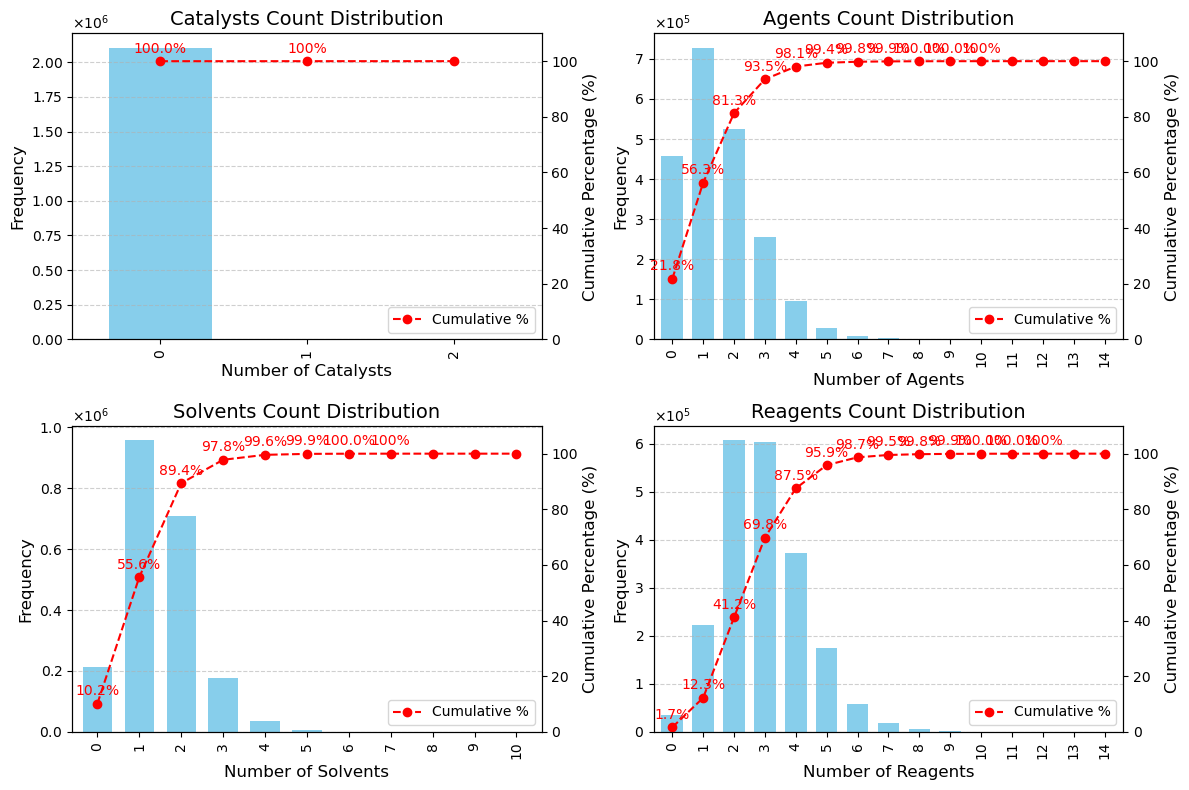

In [54]:
cols = ['Catalysts', 'Agents', 'Solvents', 'Reagents']
plot_distribution_with_cumulative(df, cols, font_size=12, figsize=(12, 8), row=2, col=2)

In [ ]:
df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased.csv')
threshold = 100
prev_len = None

print(f"초기 반응 수: {len(df)}")

while True:
    frequent_reagents, counts = get_frequent_set(df, threshold=threshold)
    df["Reagents_frequent_only"] = df["Reagents"].apply(
        lambda x: contains_only_frequent(x, frequent_reagents)
    )
    new_df = df[df["Reagents_frequent_only"]].copy()
    
    # 수렴 검사: 더 이상 줄어들지 않으면 break
    if prev_len is not None and len(new_df) == prev_len:
        break
    
    prev_len = len(new_df)
    df = new_df  # 다음 라운드에서 이 df 기준으로 다시 빈도 계산

df_final = df.drop(columns=["Reagents_frequent_only"])
print("최종 남은 반응 수:", len(df_final))
print("최종 고유 시약 수:", len(get_frequent_set(df_final, threshold)[0]))

print(f"Data Ratio: {len(df_final)/len(df)*100:.2f}%")
print(f"Reagent Ratio: {len(get_frequent_set(df_final, threshold)[0])/len(get_frequent_set(df, threshold)[0])*100:.2f}%")
cols = ['Catalysts', 'Agents', 'Solvents', 'Reagents']
plot_distribution_with_cumulative(df_final, cols)

df_final.to_csv('Raw_rxn_Final_Corrected_SetBased_100.csv', index=False, encoding='utf-8-sig')

In [ ]:
from string import digits
from typing import Tuple, List, Callable
from collections import Counter
from rdkit import Chem
from rdkit.Chem import Fragments
import typing as tp
import pandas as pd


from reaction_preprocessing import ReactionPreprocessingPipeline
from reagents_classification import HeuristicRoleClassifier
from solvents import SOLVENTS

def classify_reagents(reagent_str):
    # NaN/None/빈 값 처리
    if pd.isna(reagent_str) or not str(reagent_str).strip():
        return {
            "Catalyst": "",
            "Agent": "",
            "Solvent": "",
        }
    
    try:
        reagent_str = str(reagent_str).strip()  # 문자열로 변환
        cats, ox, red, acid, base, unspec, solv = HeuristicRoleClassifier.classify(reagent_str)
        agents = ox + red + acid + base + unspec
        return {
            "Catalyst": ";".join(cats),
            "Agent": ";".join(agents),
            "Solvent": ";".join(solv),
        }
    except Exception as e:
        print(f"⚠️ Error classifying reagents: {reagent_str} -> {e}")
        return {
            "Catalyst": "",
            "Agent": "",
            "Solvent": "",
        }

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased_100.csv', dtype=str, encoding='utf-8-sig')
classified = df["Reagents"].apply(classify_reagents)
classified_df = pd.DataFrame(classified.tolist())

df = pd.concat([df, classified_df], axis=1)
df.to_csv('Raw_rxn_Final_Corrected_SetBased_100_reclassified.csv', index=False, encoding='utf-8-sig') 

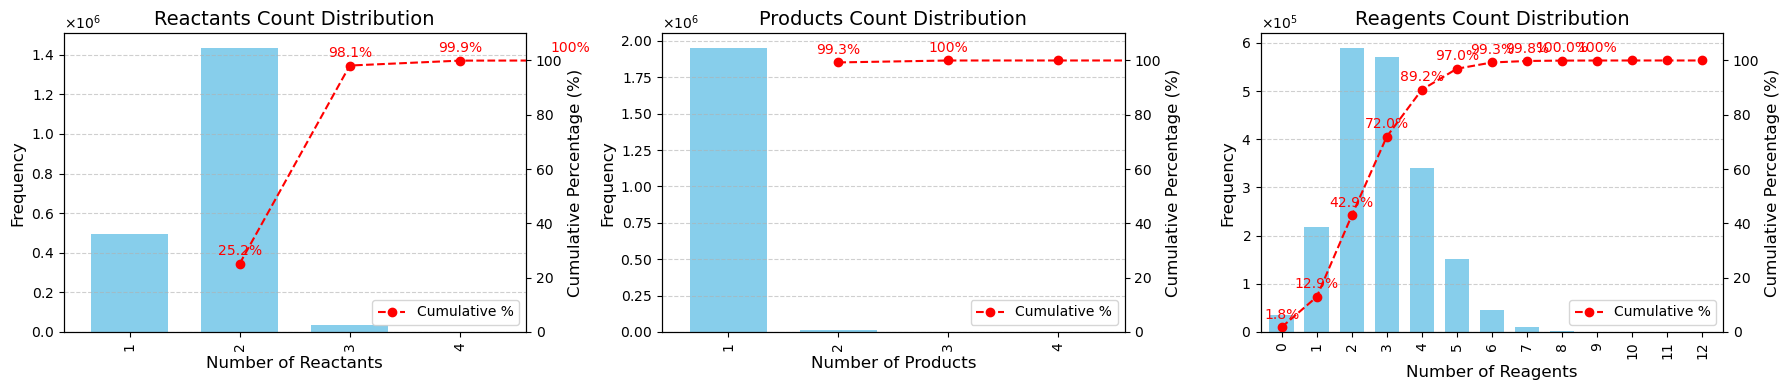

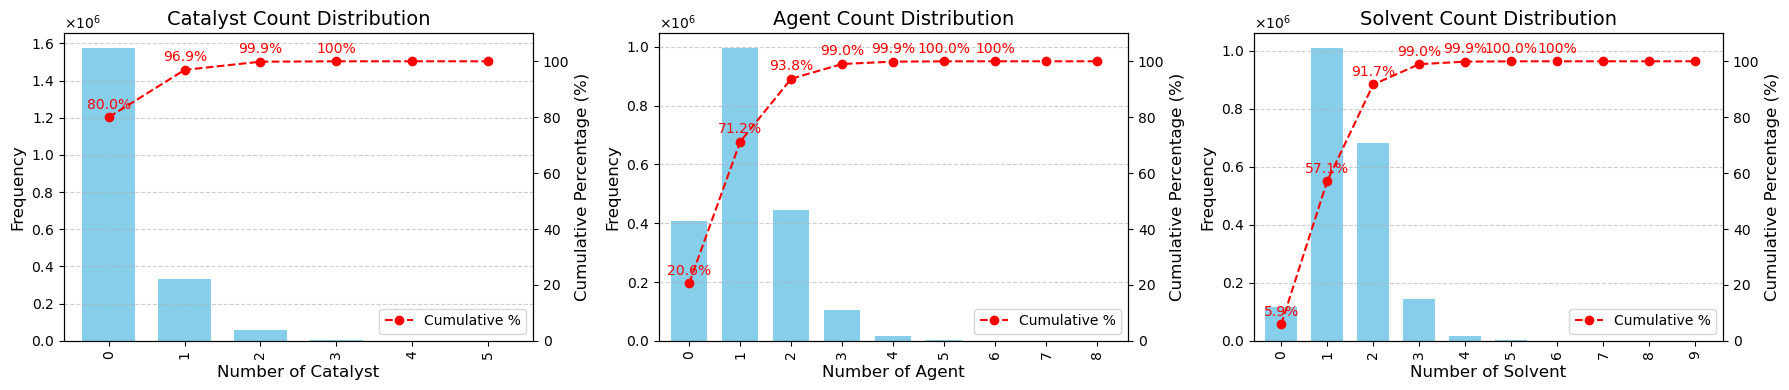

In [66]:
# df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased_below_5_reclassified.csv')
cols = ['Reactants', 'Products', 'Reagents']
plot_distribution_with_cumulative(df, cols, font_size=12, figsize=(18, 4), row=1, col=3)

cols = ['Catalyst', 'Agent', 'Solvent']
plot_distribution_with_cumulative(df, cols, font_size=12, figsize=(18, 4), row=1, col=3)


In [ ]:
import pandas as pd

# 입력 파일: 필요하면 unique 파일 대신 원본 Temp 파일로 바꿔서 사용하세요.
INPUT = "Raw_rxn_Final_Corrected_SetBased_100_reclassified.csv"
OUT_SUMMARY = "RP_conflict_summary_smiles_100.csv"
OUT_DETAIL = "RP_conflict_detail_smiles_100.csv"


def sort_cell(cell):
    if pd.isna(cell) or not str(cell).strip():
        return ""
    parts = [s.strip() for s in str(cell).split(";") if s.strip()]
    return ";".join(sorted(parts))

# 1) 데이터 로드
cols_needed = [
    "row_id", "Patent Title", "Reaction Class", "Reaction Name",
    "SMILES", "Reagents", "Main[1]_Temp"
]
df = pd.read_csv(INPUT, dtype=str, encoding="utf-8-sig", usecols=lambda c: c in cols_needed)

# 3) 같은 RP 안에서 Reagent/Temp 다양성 계산
grp = df.groupby("SMILES", dropna=False)
summary = grp.agg(
    n_rows=("SMILES", "size"),
    n_reagents=("Reagents", "nunique"),
    n_temps=("Main[1]_Temp", "nunique"),
).reset_index()

# 4) 조건: 같은 RP인데 Reagent 또는 Temp가 다른 경우
conflict_keys = summary.loc[(summary["n_reagents"] > 1) | (summary["n_temps"] > 1), "SMILES"]

summary_conflict = (
    summary[summary["SMILES"].isin(conflict_keys)]
    .sort_values(["n_rows", "n_reagents", "n_temps"], ascending=False)
    .reset_index(drop=True)
)

# 5) 상세 테이블 (행 단위)
detail_conflict = (
    df[df["SMILES"].isin(conflict_keys)]
    .sort_values(["SMILES", "Reagents", "Main[1]_Temp", "row_id"], ascending=True)
    .reset_index(drop=True)
)

# 6) 저장
summary_conflict.to_csv(OUT_SUMMARY, index=False, encoding="utf-8-sig")
detail_conflict.to_csv(OUT_DETAIL, index=False, encoding="utf-8-sig")

print(f"전체 RP 수: {summary['SMILES'].nunique():,}")
print(f"충돌 RP 수(같은 RP에서 Reagent 또는 Temp 다름): {len(summary_conflict):,}")
print(f"상세 행 수: {len(detail_conflict):,}")
print(f"평균: {len(detail_conflict) / len(summary_conflict):.2f} 행/충돌 RP")
print(f"저장 완료: {OUT_SUMMARY}, {OUT_DETAIL}")

전체 RP 수: 1,700,774
충돌 RP 수(같은 RP에서 Reagent 또는 Temp 다름): 60,341
상세 행 수: 162,714
평균: 2.70 행/충돌 RP
저장 완료: RP_conflict_summary_smiles_100.csv, RP_conflict_detail_smiles_100.csv


In [ ]:
# 같은 RP에서의 충돌 분석: 온도/Reagent 조합 분류
import pandas as pd

# 전체 데이터 로드
df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased_100_reclassified.csv', dtype=str, encoding='utf-8-sig')

print(f"분석 대상: {len(df)} 행 (전체 데이터)")
print(f"RP 종류: {df['SMILES'].nunique()} 개\n")

# RP별로 그룹화하여 같은 RP에서 뭔가 다른 경우들만 필터링
conflict_data = []
for rp, group in df.groupby('SMILES'):
    if len(group) > 1:  # 같은 RP가 2개 이상인 경우만
        conflict_data.extend(group.values)

df_conflict = pd.DataFrame(conflict_data, columns=df.columns)

print(f"같은 RP에서 충돌 있는 경우: {len(df_conflict)} 행")
print(f"충돌 RP 종류: {df_conflict['SMILES'].nunique()} 개\n")

# 분류 카테고리별 통계
conflict_types = {
    'reagent_and_temp_diff': 0,  # RP 같음, Reagent 다름, 온도 다름
    'reagent_same_temp_diff': 0,  # RP 같음, Reagent 같음, 온도 다름
    'reagent_diff_temp_same': 0,  # RP 같음, Reagent 다름, 온도 같음
}

rp_conflict_breakdown = []  # 각 RP별 상세 정보

# 각 RP 그룹 분석
for rp, group in df_conflict.groupby('SMILES'):
    group_reagents = group['Reagents'].unique()
    group_temps = group['Main[1]_Temp'].unique()
    
    n_rows = len(group)
    n_reagent_variants = len(group_reagents)
    n_temp_variants = len(group_temps)
    
    # 이 그룹의 분류
    types_in_group = {
        'reagent_and_temp_diff': 0,
        'reagent_same_temp_diff': 0,
        'reagent_diff_temp_same': 0,
    }
    
    # 모든 행 쌍을 비교
    group_list = group.reset_index(drop=True)
    for i in range(len(group_list)):
        for j in range(i + 1, len(group_list)):
            row_i = group_list.iloc[i]
            row_j = group_list.iloc[j]
            
            reagent_same = row_i['Reagents'] == row_j['Reagents']
            temp_same = row_i['Main[1]_Temp'] == row_j['Main[1]_Temp']
            
            if not reagent_same and not temp_same:
                types_in_group['reagent_and_temp_diff'] += 1
            elif reagent_same and not temp_same:
                types_in_group['reagent_same_temp_diff'] += 1
            elif not reagent_same and temp_same:
                types_in_group['reagent_diff_temp_same'] += 1
    
    # 전체 통계에 추가
    for key in conflict_types:
        conflict_types[key] += types_in_group[key]
    
    # RP별 상세 정보
    rp_conflict_breakdown.append({
        'SMILES': rp,
        'n_rows': n_rows,
        'n_reagent_variants': n_reagent_variants,
        'n_temp_variants': n_temp_variants,
        'reagent_and_temp_diff_pairs': types_in_group['reagent_and_temp_diff'],
        'reagent_same_temp_diff_pairs': types_in_group['reagent_same_temp_diff'],
        'reagent_diff_temp_same_pairs': types_in_group['reagent_diff_temp_same'],
    })

# 통계 출력
print("=" * 70)
print("【 같은 RP에서의 충돌 유형별 분석 】")
print("=" * 70)
print(f"\n1️⃣  RP는 같고 Reagent + 온도 모두 다른 경우:")
print(f"   행 쌍의 개수: {conflict_types['reagent_and_temp_diff']:,}")

print(f"\n2️⃣  RP + Reagent는 같은데 온도만 다른 경우:")
print(f"   행 쌍의 개수: {conflict_types['reagent_same_temp_diff']:,}")

print(f"\n3️⃣  RP + 온도는 같은데 Reagent만 다른 경우:")
print(f"   행 쌍의 개수: {conflict_types['reagent_diff_temp_same']:,}")

total_pairs = sum(conflict_types.values())
print(f"\n【 전체 비교 쌍 수 】: {total_pairs:,}")

# RP별 분석 (평균)
df_breakdown = pd.DataFrame(rp_conflict_breakdown)
print(f"\n" + "=" * 70)
print("【 RP별 평균 통계 】")
print("=" * 70)
print(f"\n한 RP당 평균 행 수: {df_breakdown['n_rows'].mean():.2f}")
print(f"한 RP당 평균 Reagent 변종: {df_breakdown['n_reagent_variants'].mean():.2f}")
print(f"한 RP당 평균 온도 변종: {df_breakdown['n_temp_variants'].mean():.2f}")

print(f"\n한 RP당 평균 행 쌍 비율:")
print(f"  - Reagent + 온도 모두 다름: {df_breakdown['reagent_and_temp_diff_pairs'].mean():.2f} 쌍/RP")
print(f"  - Reagent 같고 온도만 다름: {df_breakdown['reagent_same_temp_diff_pairs'].mean():.2f} 쌍/RP")
print(f"  - 온도 같고 Reagent만 다름: {df_breakdown['reagent_diff_temp_same_pairs'].mean():.2f} 쌍/RP")

# 상세 결과 저장
df_breakdown.to_csv('conflict_analysis_by_rp_type.csv', index=False, encoding='utf-8-sig')
print(f"\n✅ 상세 결과 저장: conflict_analysis_by_rp_type.csv")

# 요약 통계
summary_stats = {
    'Category': [
        'Reagent+Temp Different',
        'Reagent Same, Temp Different',
        'Temp Same, Reagent Different',
        'TOTAL'
    ],
    'Pair_Count': [
        conflict_types['reagent_and_temp_diff'],
        conflict_types['reagent_same_temp_diff'],
        conflict_types['reagent_diff_temp_same'],
        total_pairs
    ],
    'Percentage': [
        f"{conflict_types['reagent_and_temp_diff']/total_pairs*100:.2f}%" if total_pairs > 0 else "N/A",
        f"{conflict_types['reagent_same_temp_diff']/total_pairs*100:.2f}%" if total_pairs > 0 else "N/A",
        f"{conflict_types['reagent_diff_temp_same']/total_pairs*100:.2f}%" if total_pairs > 0 else "N/A",
        "100.00%"
    ]
}

df_summary = pd.DataFrame(summary_stats)
df_summary.to_csv('conflict_analysis_summary_100.csv', index=False, encoding='utf-8-sig')
print(f"✅ 요약 통계 저장: conflict_analysis_summary.csv\n")
print(df_summary.to_string(index=False))

분석 대상: 1968009 행 (전체 데이터)
RP 종류: 1700774 개

같은 RP에서 충돌 있는 경우: 475833 행
충돌 RP 종류: 208598 개

【 같은 RP에서의 충돌 유형별 분석 】

1️⃣  RP는 같고 Reagent + 온도 모두 다른 경우:
   행 쌍의 개수: 121,251

2️⃣  RP + Reagent는 같은데 온도만 다른 경우:
   행 쌍의 개수: 34,992

3️⃣  RP + 온도는 같은데 Reagent만 다른 경우:
   행 쌍의 개수: 232,661

【 전체 비교 쌍 수 】: 388,904

【 RP별 평균 통계 】

한 RP당 평균 행 수: 2.28
한 RP당 평균 Reagent 변종: 2.08
한 RP당 평균 온도 변종: 1.34

한 RP당 평균 행 쌍 비율:
  - Reagent + 온도 모두 다름: 0.58 쌍/RP
  - Reagent 같고 온도만 다름: 0.17 쌍/RP
  - 온도 같고 Reagent만 다름: 1.12 쌍/RP

✅ 상세 결과 저장: conflict_analysis_by_rp_type.csv
✅ 요약 통계 저장: conflict_analysis_summary.csv

                    Category  Pair_Count Percentage
      Reagent+Temp Different      121251     31.18%
Reagent Same, Temp Different       34992      9.00%
Temp Same, Reagent Different      232661     59.82%
                       TOTAL      388904    100.00%


In [ ]:
# 원본에서 규칙 적용해서 RP 통합 + 선택이유 기록
import pandas as pd

# 원본 데이터 로드
df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased_100_reclassified.csv', dtype=str, encoding='utf-8-sig')

print(f"원본 행 수: {len(df):,}")

def parse_set(reagents_str):
    if pd.isna(reagents_str):
        return set()
    s = str(reagents_str).strip()
    if not s or s.lower() in ['nan', 'none']:
        return set()
    items = [x.strip() for x in s.split(';') if x.strip() and x.strip().lower() not in ['nan', 'none']]
    return set(items)

def get_temp_value(temp_str):
    if pd.isna(temp_str):
        return float('-inf')
    s = str(temp_str).strip()
    if not s or s.lower() in ['nan', 'none']:
        return float('-inf')
    try:
        return float(s)
    except:
        return float('-inf')

# 통합 결과 저장
merged_data = []
selection_records = []  # RP_key, 원본 인덱스, is_selected, reason

rp_counter = 0

for rp, group_df in df.groupby('SMILES', dropna=False):
    rp_counter += 1
    rp_key = f"RP_{rp_counter}"
    
    if len(group_df) == 1:
        # 같은 RP가 1개면 자동 선택
        idx = group_df.index[0]
        row = group_df.iloc[0].copy()
        merged_data.append(row)
        
        selection_records.append({
            'RP_key': rp_key,
            'original_index': idx,
            'is_selected': True,
            'selection_reason': 'Only option (single reaction)',
            'SMILES': rp
        })
        continue
    
    # Reagents set별로 그룹화
    row_infos = []
    for idx, row in group_df.iterrows():
        reagents_set = parse_set(row['Reagents'])
        temp = get_temp_value(row.get('Main[1]_Temp', ''))
        row_infos.append({
            'original_idx': idx,
            'set': reagents_set,
            'set_size': len(reagents_set),
            'temp': temp,
            'row': row
        })
    
    # 1단계: 같은 Reagents set에서 온도 높은 것만 선택
    set_to_rows = {}
    for info in row_infos:
        key = frozenset(info['set'])
        if key not in set_to_rows:
            set_to_rows[key] = []
        set_to_rows[key].append(info)
    
    representatives = []
    for set_key, items in set_to_rows.items():
        best = max(items, key=lambda x: x['temp'])
        representatives.append(best)
        
        # 같은 set에서 온도 낮은 것들은 탈락
        for item in items:
            if item['original_idx'] != best['original_idx']:
                temp_display = f"{item['temp']:.1f}" if item['temp'] > float('-inf') else 'unknown'
                best_temp_display = f"{best['temp']:.1f}" if best['temp'] > float('-inf') else 'unknown'
                selection_records.append({
                    'RP_key': rp_key,
                    'original_index': item['original_idx'],
                    'is_selected': False,
                    'selection_reason': f'Lower temperature ({temp_display}°C) than selected ({best_temp_display}°C)',
                    'SMILES': rp
                })
    
    # 2단계: 부분집합 관계 확인해서 큰 set만 유지
    final_selected = []
    for rep in representatives:
        is_subset = False
        larger_set_info = None
        for other in representatives:
            if rep['set'] != other['set'] and rep['set'] < other['set']:
                is_subset = True
                larger_set_info = other
                break
        
        if not is_subset:
            final_selected.append(rep)
            merged_data.append(rep['row'].copy())
            
            temp_display = f"{rep['temp']:.1f}" if rep['temp'] > float('-inf') else 'unknown'
            selection_records.append({
                'RP_key': rp_key,
                'original_index': rep['original_idx'],
                'is_selected': True,
                'selection_reason': f'Largest reagent set (size={rep["set_size"]}, temp={temp_display}°C)',
                'SMILES': rp
            })
        else:
            # 부분집합이므로 탈락
            reagents_display = ';'.join(sorted(rep['set'])) if rep['set'] else '(empty)'
            larger_reagents = ';'.join(sorted(larger_set_info['set'])) if larger_set_info['set'] else '(empty)'
            
            selection_records.append({
                'RP_key': rp_key,
                'original_index': rep['original_idx'],
                'is_selected': False,
                'selection_reason': f'Cannot merge - subset [{reagents_display}] < larger set [{larger_reagents}]',
                'SMILES': rp
            })

# 1️⃣ 통합된 데이터 저장
df_merged = pd.DataFrame(merged_data).reset_index(drop=True)
df_merged.to_csv('Raw_rxn_Final_Corrected_SetBased_100_reclassified_RP_merged.csv', index=False, encoding='utf-8-sig')

print(f"\n✅ 통합 결과 저장: Raw_rxn_Final_Corrected_SetBased_100_reclassified_RP_merged.csv")
print(f"   통합 후 행 수: {len(df_merged):,}")
print(f"   제거된 행 수: {len(df) - len(df_merged):,}")

# 2️⃣ 선택이유 CSV 저장 (모든 반응 포함)
df_selection = pd.DataFrame(selection_records)
df_selection.to_csv('RP_selection_details.csv', index=False, encoding='utf-8-sig')

print(f"\n✅ 선택/탈락 이유 저장: RP_selection_details.csv")

# 3️⃣ 통계
selected_count = df_selection['is_selected'].sum()
not_selected_count = (~df_selection['is_selected']).sum()

print(f"\n【 선택/탈락 현황 】")
print(f"선택된 반응: {selected_count:,}")
print(f"탈락된 반응: {not_selected_count:,}")
print(f"총 반응: {len(df_selection):,}")

# 4️⃣ 탈락 이유별 분류
print(f"\n【 탈락 이유 분류 】")
not_selected = df_selection[~df_selection['is_selected']]
if len(not_selected) > 0:
    for reason in not_selected['selection_reason'].unique():
        count = (not_selected['selection_reason'] == reason).sum()
        print(f"  - {reason}: {count:,}")

# 5️⃣ 못 합쳐진 RP 분석 (부분집합 관계가 없어서 여러 선택지가 남은 경우)
print(f"\n【 못 합쳐진 RP (여러 Reagent sets 유지) 】")
not_unified_rps = []
for rp_key in df_selection['RP_key'].unique():
    rp_group = df_selection[df_selection['RP_key'] == rp_key]
    selected_rows = rp_group[rp_group['is_selected']]
    
    if len(selected_rows) > 1:
        not_unified_rps.append({
            'RP_key': rp_key,
            'num_selected': len(selected_rows),
            'SMILES': rp_group['SMILES'].iloc[0]
        })

if not_unified_rps:
    print(f"총 {len(not_unified_rps):,} 개의 RP에서 여러 Reagent sets가 유지됨")
    print(f"\n예시 (처음 10개):")
    for info in not_unified_rps[:10]:
        print(f"  {info['RP_key']}: {info['num_selected']}개 반응 유지")
else:
    print("✅ 모든 RP가 성공적으로 1개 반응으로 통합됨!")

print(f"\n\n【 선택 이유별 분류 】")
reason_counts = df_selection[df_selection['is_selected']]['selection_reason'].value_counts()
for reason, count in reason_counts.items():
    print(f"✅ {reason}: {count:,}")

print(f"\n\n【 예시 (처음 20개 기록) 】")
print(df_selection[['RP_key', 'original_index', 'is_selected', 'selection_reason']].head(20).to_string(index=False))

원본 행 수: 1,968,009

✅ 통합 결과 저장: Raw_rxn_Final_Corrected_SetBased_100_reclassified_RP_merged.csv
   통합 후 행 수: 1,772,933
   제거된 행 수: 195,076


In [ ]:
df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased_100_reclassified_RP_merged.csv')
print(f"최종 데이터 로드 완료: {len(df)} rows")
df.head(3)

In [ ]:
def remove_unwanted_agents(cell):
    if pd.isna(cell) or not cell.strip():
        return ""
    agents = [s.strip() for s in cell.split(";") if s.strip()]
    filtered = [s for s in agents if s not in ["O", "N#N", 'O.O']]
    filtered_sorted = sorted(filtered)
    return ";".join(filtered_sorted)


df = pd.read_csv('Raw_rxn_Final_Corrected_SetBased_100_reclassified_RP_merged.csv')
print(f"Raw_rxn_Final_Corrected_SetBased_100_reclassified_RP_merged 데이터 로드 완료: {len(df)} rows")

print("불필요한 시약 제거 전 (O, N#N, O.O)")
cols = ['Catalyst', 'Agent', 'Solvent']
plot_distribution_with_cumulative(df, cols, font_size=12, figsize=(18, 4), row=1, col=3)

print("불필요한 시약 제거 중... (O, N#N, O.O)")
# Catalysts, Solvents, Agents 각각에 적용
df['Catalyst'] = df['Catalyst'].apply(remove_unwanted_agents)
df['Solvent'] = df['Solvent'].apply(remove_unwanted_agents)
df['Agent'] = df['Agent'].apply(remove_unwanted_agents)
df['Reagents'] = df['Reagents'].apply(remove_unwanted_agents)

print("불필요한 시약 제거 후 (O, N#N, O.O)")
cols = ['Catalyst', 'Agent', 'Solvent']
plot_distribution_with_cumulative(df, cols, font_size=12, figsize=(18, 4), row=1, col=3)


def sort_cell(cell):
    if pd.isna(cell) or not cell.strip():
        return ""
    parts = [s.strip() for s in cell.split(";") if s.strip()]
    parts_sorted = sorted(parts)
    return ";".join(parts_sorted)

print("고유 반응만 남기는 중")

# 키 생성
df["RP_key"] = df["SMILES"]
df["Full_key"] = df["RP_key"] + "::" + df["Reagents"].astype(str)
df["Full_key_temp"] = df["Full_key"] + "::(" + df["Main[1]_Temp"].astype(str) + ")"

print("RP_key unique   :", df_keys["RP_key"].nunique())
print("Full_key unique :", df_keys["Full_key"].nunique())
print("Full_key_temp unique :", df_keys["Full_key_temp"].nunique())

df_unique = df.drop_duplicates(subset="Full_key_temp", keep="first").copy()
print("rows after unique Full_key_temp :", len(df_unique))

cols_2 = [
    'row_id', 'Patent Title', 'Date', 'Quality', 'Reaction Class', 'Reaction Name',
    'SMILES', 'Reagents', 'Main[1]_Temp', 'Catalyst', 'Agent', 'Solvent']

df_unique = df_unique[cols_2]

print("고유 반응만 남긴 후 데이터 로드 완료")
cols = ['Catalyst', 'Agent', 'Solvent']
plot_distribution_with_cumulative(df_unique, cols, font_size=12, figsize=(18, 4), row=1, col=3)


print("시약 개수별로 제한하는 중...")
df_5 = df[(df["Reagents"].apply(count_reagents) >= 1) & (df["Reagents"].apply(count_reagents) <= 5)]
print(f"1~5개 시약 반응 수: {len(df_5)}")

df_limited = df[df["Catalyst"].apply(count_reagents) <= 1 & df["Agent"].apply(count_reagents) <= 2 & df["Solvent"].apply(count_reagents) <= 2]
print(f"시약별로 개수 제한된 반응 수: {len(df_limited)}")

print("빈도 기반으로 시약 필터링하는 중...(100회 이상 등장하는 시약만 남기도록)")
df = df_limited
threshold = 100
prev_len = None

print(f"초기 반응 수: {len(df)}")

while True:
    frequent_reagents, counts = get_frequent_set(df, threshold=threshold)
    df["Reagents_frequent_only"] = df["Reagents"].apply(
        lambda x: contains_only_frequent(x, frequent_reagents)
    )
    new_df = df[df["Reagents_frequent_only"]].copy()
    
    # 수렴 검사: 더 이상 줄어들지 않으면 break
    if prev_len is not None and len(new_df) == prev_len:
        break
    
    prev_len = len(new_df)
    df = new_df  # 다음 라운드에서 이 df 기준으로 다시 빈도 계산

df_final = df.drop(columns=["Reagents_frequent_only"])
print("최종 남은 반응 수:", len(df_final))
print("최종 고유 시약 수:", len(get_frequent_set(df_final, threshold)[0]))

print(f"Data Ratio: {len(df_final)/len(df)*100:.2f}%")
print(f"Reagent Ratio: {len(get_frequent_set(df_final, threshold)[0])/len(get_frequent_set(df, threshold)[0])*100:.2f}%")
cols = ['Catalysts', 'Agents', 'Solvents', 'Reagents']
plot_distribution_with_cumulative(df_final, cols)

df_final.to_csv('P2026_Final.csv', index=False, encoding='utf-8-sig')


In [2]:
import pandas as pd

df = pd.read_csv('P2026_Final.csv')
print(f"P2026_Final.csv: {len(df)} rows")

C:\Users\MICC\AppData\Local\Temp\ipykernel_25952\3001539207.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('P2026_Final.csv')


P2026_Final.csv: 1555946 rows


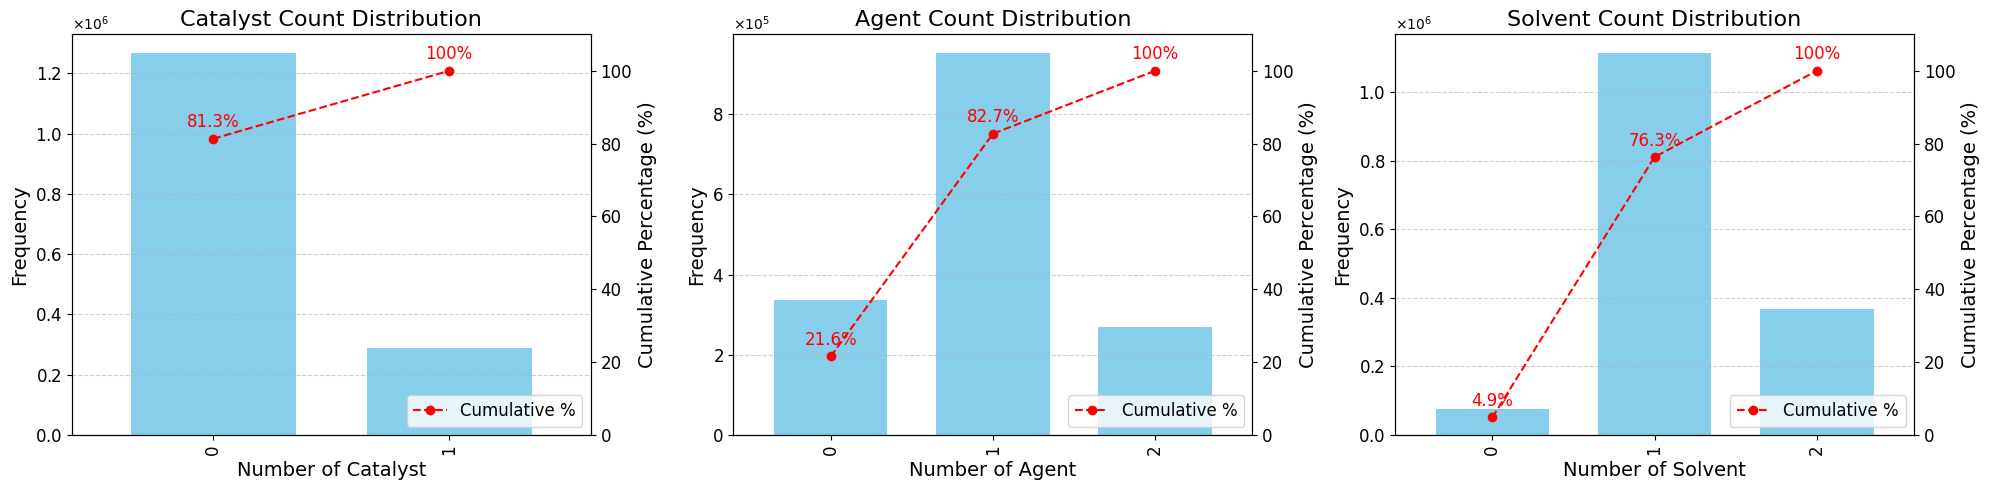

In [ ]:
cols = ['Catalyst', 'Agent', 'Solvent', ]
plot_distribution_with_cumulative(df, cols, font_size=14, figsize=(20, 5), row=1, col=3)

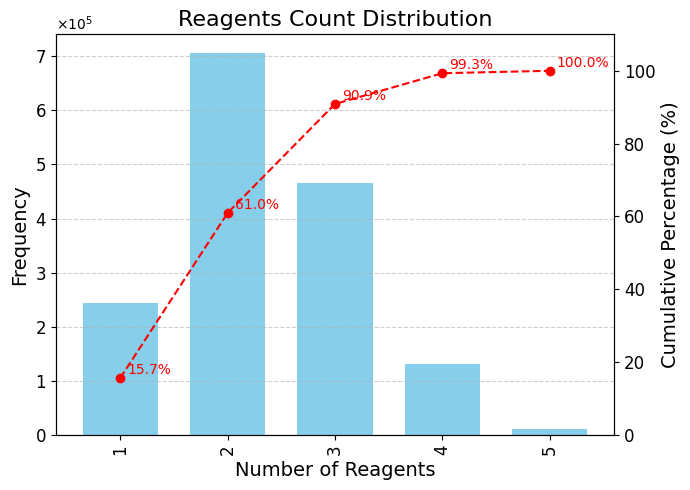

In [20]:
def plot_distribution_single(df, col, font_size=14, figsize=(7, 5)):
    def count_reagents(cell):
        if pd.isna(cell) or not cell.strip():
            return 0
        return len([x for x in cell.split(";") if x.strip()])

    count_series = df[col].apply(count_reagents)
    dist = count_series.value_counts().sort_index()
    cumulative = dist.cumsum() / dist.sum() * 100

    fig, ax1 = plt.subplots(figsize=figsize)
    dist.plot(kind="bar", ax=ax1, color='skyblue', width=0.7)

    ax1.set_title(f"{col} Count Distribution", fontsize=font_size + 2)
    ax1.set_xlabel(f"Number of {col}", fontsize=font_size)
    ax1.set_ylabel("Frequency", fontsize=font_size)
    ax1.tick_params(axis='x', labelsize=font_size - 2)
    ax1.tick_params(axis='y', labelsize=font_size - 2)
    ax1.yaxis.set_major_formatter(mtick.ScalarFormatter(useMathText=True))
    ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

    ax2 = ax1.twinx()
    x_pos = range(len(cumulative))                                          # ← 수정
    ax2.plot(x_pos, cumulative.values, color='red', marker='o', linestyle='--')
    ax2.set_ylabel("Cumulative Percentage (%)", fontsize=font_size)
    ax2.tick_params(axis='y', labelsize=font_size - 2)
    ax2.set_ylim(0, 110)

    shown_100 = False
    for x, y in zip(x_pos, cumulative.values):                             # ← 수정
        if y >= 99.99:
            if shown_100:
                continue
            shown_100 = True
        ax2.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                     xytext=(5, 3), fontsize=font_size - 4, color='red')

    plt.tight_layout()
    plt.show()

plot_distribution_single(df, 'Reagents', font_size=14, figsize=(7, 5))